In [1]:
# --- Install Required Dependencies ---
# Run this cell first to install all required packages

%pip install numpy pandas matplotlib seaborn torch torchvision scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [2]:
# Enhanced simulation: more realistic patient-day events
# Replace your original simulation loop with this for more complex, realistic data
import numpy as np
import pandas as pd

n_patients = 1000
n_days = 365
np.random.seed(42)
glu_base = np.random.normal(120, 15, n_patients)
ins_base = np.random.normal(40, 10, n_patients)

records = []
for pid in range(n_patients):
    g_mean = glu_base[pid]
    ins_dose = ins_base[pid]
    adherence = 1.0
    recent_missed = 0
    recent_illness = 0
    recent_stress = 0
    for day in range(n_days):
        date = pd.Timestamp('2020-01-01') + pd.Timedelta(days=day)
        sleep_quality = np.random.uniform(0.5, 1.0)
        exercise_flag = np.random.binomial(1, 0.3)
        meal_variability = np.random.uniform(0, 1)
        stress_index = np.random.uniform(0, 1)
        illness_flag = np.random.binomial(1, 0.05)
        missed_insulin = np.random.binomial(1, 0.05)
        # Update streaks
        if missed_insulin:
            recent_missed = min(recent_missed + 1, 5)
        else:
            recent_missed = max(recent_missed - 1, 0)
        if illness_flag:
            recent_illness = min(recent_illness + 1, 5)
        else:
            recent_illness = max(recent_illness - 1, 0)
        if stress_index > 0.8:
            recent_stress = min(recent_stress + 1, 5)
        else:
            recent_stress = max(recent_stress - 1, 0)
        # Adherence logic
        if missed_insulin:
            adherence -= 0.1
            adherence = max(adherence, 0)
            ins_dose = 0
        else:
            adherence += 0.02
            adherence = min(adherence, 1)
            ins_dose = ins_base[pid] * adherence
        # Glucose excursions
        pct_hypo = np.random.beta(2, 20) * 100
        pct_hyper = np.random.beta(2, 10) * 100
        g_std = np.random.normal(20, 5)
        # Base glucose
        g_mean += np.random.normal(0, 2)
        # Delayed effects
        if recent_missed > 0:
            g_mean += 8 * recent_missed
            g_std += 2 * recent_missed
        if recent_illness > 0:
            g_mean += 5 * recent_illness
            g_std += 3 * recent_illness
        if recent_stress > 0:
            g_mean += 4 * recent_stress
            g_std += 2 * recent_stress
        # Interactions
        if missed_insulin and stress_index > 0.8:
            g_mean += 20
            g_std += 10
        if exercise_flag and sleep_quality > 0.8:
            g_mean -= 10
            g_std -= 2
        # Rare severe events
        if np.random.rand() < 0.01:
            g_mean += np.random.choice([60, -40])
            g_std += np.random.choice([30, 40])
        # Real-world feedback: if glucose is high, patient increases insulin
        if g_mean > 180 and np.random.rand() < 0.7:
            # 70% chance patient responds with extra insulin
            ins_dose += np.random.uniform(4, 12)
            adherence += np.random.uniform(0.05, 0.15)
            adherence = min(adherence, 1)
            g_mean -= np.random.uniform(10, 30)  # effect of correction
        # If glucose is low, patient may reduce insulin
        if g_mean < 70 and np.random.rand() < 0.5:
            ins_dose -= np.random.uniform(2, 6)
            ins_dose = max(ins_dose, 0)
            g_mean += np.random.uniform(5, 20)
        # Clamp values
        g_mean = np.clip(g_mean, 40, 400)
        g_std = np.clip(g_std, 5, 80)
        records.append({
            'patient_id': pid,
            'date': date,
            'g_mean': g_mean,
            'g_std': g_std,
            'pct_hypo': pct_hypo,
            'pct_hyper': pct_hyper,
            'insulin_dose': ins_dose,
            'insulin_adherence': adherence,
            'sleep_quality': sleep_quality,
            'exercise_flag': exercise_flag,
            'meal_variability': meal_variability,
            'stress_index': stress_index,
            'illness_flag': illness_flag,
            'missed_insulin': missed_insulin
        })

# After this, use the same DataFrame creation and risk labeling code as before.


In [3]:
   df = pd.DataFrame(records)
   df = df.sort_values(['patient_id', 'date']).reset_index(drop=True)

# Exploratory Data Analysis (EDA) of Synthetic Glucose Risk Dataset

This section visualizes and explains the key signals in the synthetic dataset:
- Glucose values (mean, std, % hypo/hyper)
- Insulin usage (dose, adherence)
- Lifestyle features (sleep, exercise, meal variability)
- External context (stress, illness)

We use a single patient as an example for clarity.


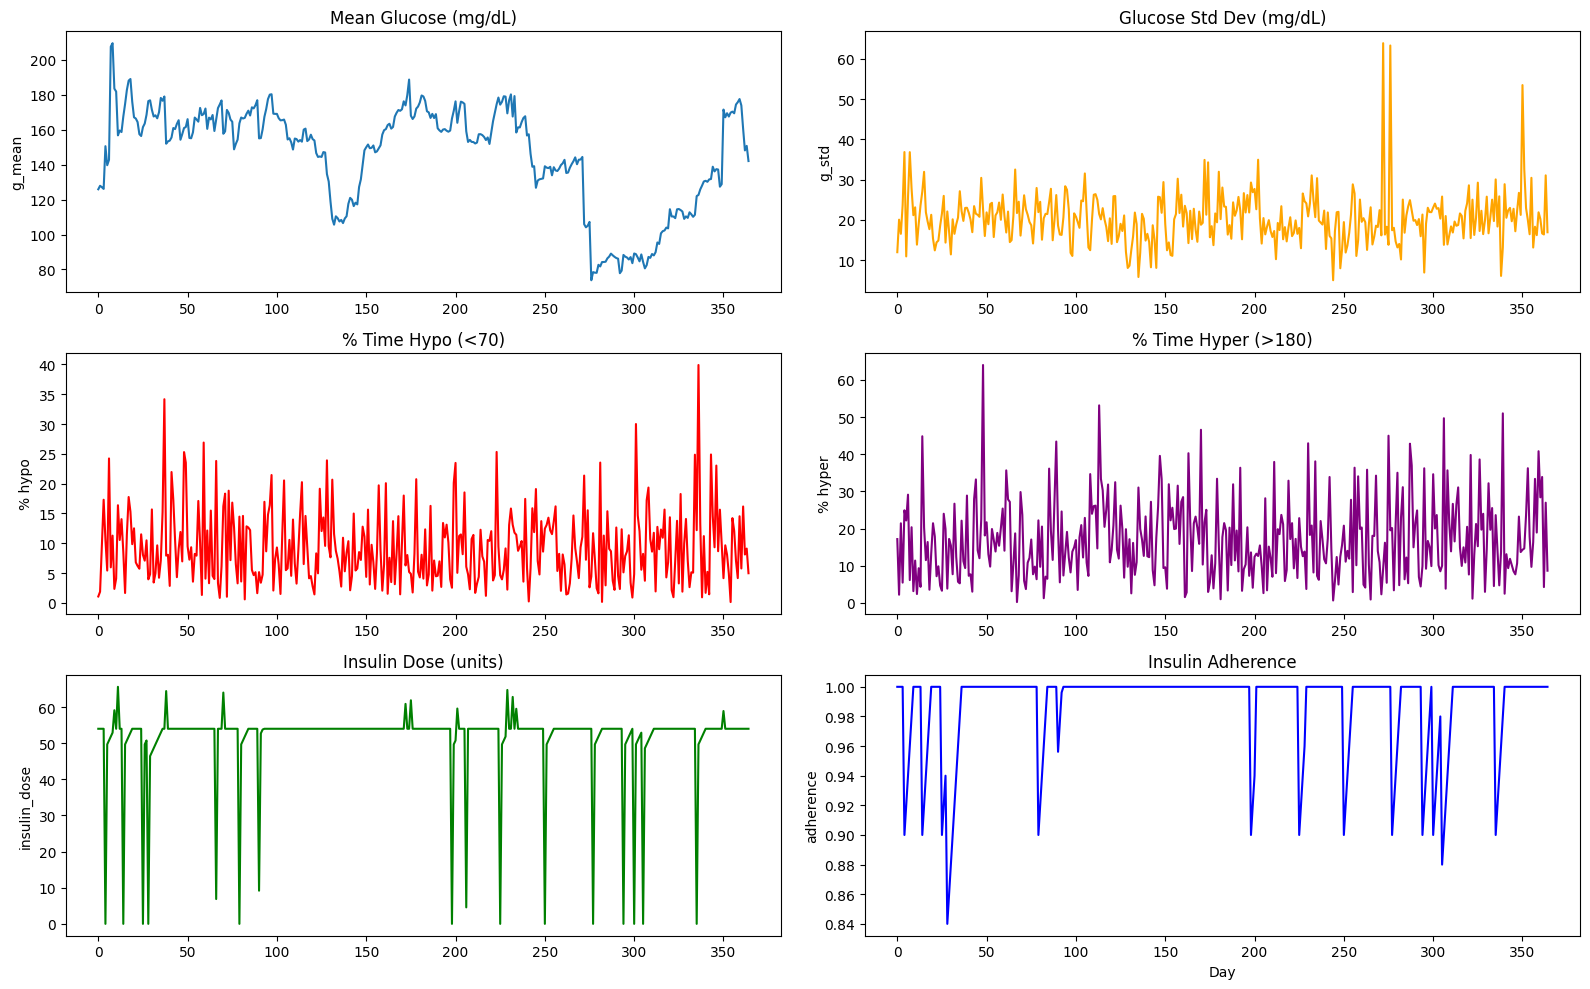

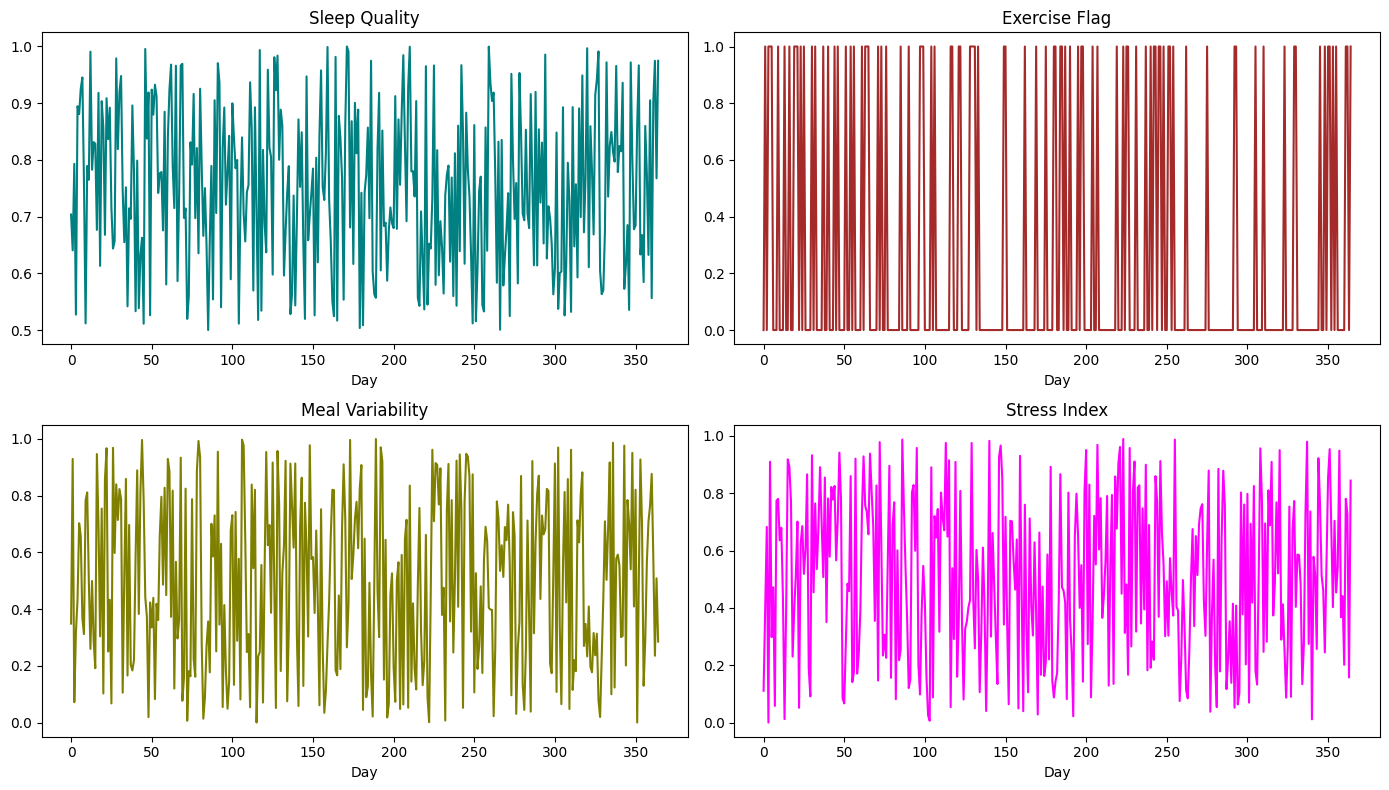

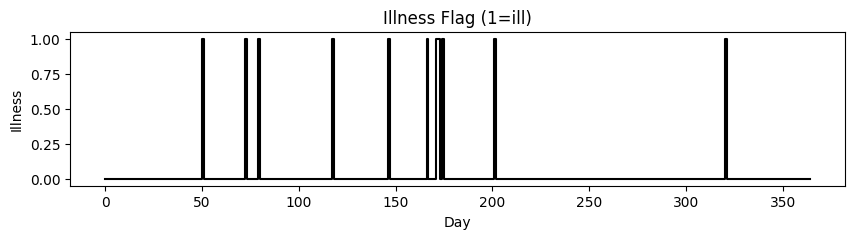

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select a single patient for demonstration
pid = 0
df_patient = df[df['patient_id'] == pid].copy()

plt.figure(figsize=(16, 10))

# Glucose mean and std
g1 = plt.subplot(3, 2, 1)
df_patient['g_mean'].plot(ax=g1, title='Mean Glucose (mg/dL)')
g1.set_ylabel('g_mean')

g2 = plt.subplot(3, 2, 2)
df_patient['g_std'].plot(ax=g2, title='Glucose Std Dev (mg/dL)', color='orange')
g2.set_ylabel('g_std')

# % Hypo and % Hyper
g3 = plt.subplot(3, 2, 3)
df_patient['pct_hypo'].plot(ax=g3, title='% Time Hypo (<70)', color='red')
g3.set_ylabel('% hypo')

g4 = plt.subplot(3, 2, 4)
df_patient['pct_hyper'].plot(ax=g4, title='% Time Hyper (>180)', color='purple')
g4.set_ylabel('% hyper')

# Insulin dose and adherence
g5 = plt.subplot(3, 2, 5)
df_patient['insulin_dose'].plot(ax=g5, title='Insulin Dose (units)', color='green')
g5.set_ylabel('insulin_dose')

g6 = plt.subplot(3, 2, 6)
df_patient['insulin_adherence'].plot(ax=g6, title='Insulin Adherence', color='blue')
g6.set_ylabel('adherence')

g6.set_xlabel('Day')
plt.tight_layout()
plt.show()

# Lifestyle and context features
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
df_patient['sleep_quality'].plot(ax=axes[0,0], title='Sleep Quality', color='teal')
df_patient['exercise_flag'].plot(ax=axes[0,1], title='Exercise Flag', color='brown')
df_patient['meal_variability'].plot(ax=axes[1,0], title='Meal Variability', color='olive')
df_patient['stress_index'].plot(ax=axes[1,1], title='Stress Index', color='magenta')
for ax in axes.flat:
    ax.set_xlabel('Day')
plt.tight_layout()
plt.show()

# Illness flag
plt.figure(figsize=(10,2))
df_patient['illness_flag'].plot(drawstyle='steps-post', title='Illness Flag (1=ill)', color='black')
plt.xlabel('Day')
plt.ylabel('Illness')
plt.show()


## Defining Risk Outcome Labels

We define risk outcome labels as the probability of deterioration in the next 7, 30, and 90 days. Deterioration events are defined as:
- Sustained hyperglycemia (g_mean > 180)
- Sustained hypoglycemia (g_mean < 70)
- Missed insulin streaks (≥2 missed days in 3)
- High glucose volatility (g_std > 30)

For each day, we compute the probability of a deterioration event in the next 7, 30, and 90 days using rolling windows.


In [5]:
# Define deterioration events
# - Hyperglycemia: g_mean > 180
# - Hypoglycemia: g_mean < 70
# - Missed insulin streak: >=2 missed in 3 days
# - High volatility: g_std > 30

df['hyper_event'] = (df['g_mean'] > 180).astype(int)
df['hypo_event'] = (df['g_mean'] < 70).astype(int)
df['volatility_event'] = (df['g_std'] > 30).astype(int)
df['missed_streak'] = df.groupby('patient_id')['missed_insulin'].rolling(3).sum().reset_index(level=0, drop=True) >= 2

def deterioration_event(row):
    return (
        row['hyper_event'] or
        row['hypo_event'] or
        row['volatility_event'] or
        row['missed_streak']
    )

df['deterioration'] = df.apply(deterioration_event, axis=1).astype(int)

# Compute risk probabilities for next 7, 30, 90 days
for window in [7, 30, 90]:
    df[f'risk_{window}d_prob'] = (
        df.groupby('patient_id')['deterioration']
        .apply(lambda g: g.shift(-1).rolling(window, min_periods=1).mean())
        .reset_index(level=0, drop=True)
    )

# Show a sample
print(df[['patient_id', 'date', 'g_mean', 'g_std', 'deterioration', 'risk_7d_prob', 'risk_30d_prob', 'risk_90d_prob']].head(10))


   patient_id       date      g_mean      g_std  deterioration  risk_7d_prob  \
0           0 2020-01-01  125.925263  11.962201              0      0.000000   
1           0 2020-01-02  127.932682  20.039821              0      0.000000   
2           0 2020-01-03  127.114117  16.526434              0      0.000000   
3           0 2020-01-04  126.137723  23.643424              0      0.250000   
4           0 2020-01-05  150.609984  36.826987              1      0.200000   
5           0 2020-01-06  139.703488  10.917512              0      0.166667   
6           0 2020-01-07  142.799487  25.627174              0      0.285714   
7           0 2020-01-08  207.624718  36.805957              1      0.428571   
8           0 2020-01-09  209.602056  27.745101              1      0.571429   
9           0 2020-01-10  183.564164  21.153505              1      0.714286   

   risk_30d_prob  risk_90d_prob  
0       0.000000       0.000000  
1       0.000000       0.000000  
2       0.000000 

## Visualizing Risk Probabilities

We now visualize the computed risk probabilities (`risk_7d_prob`, `risk_30d_prob`, `risk_90d_prob`) for a single patient, along with their glucose mean and deterioration events. This helps illustrate how risk evolves over time and how it relates to underlying signals.


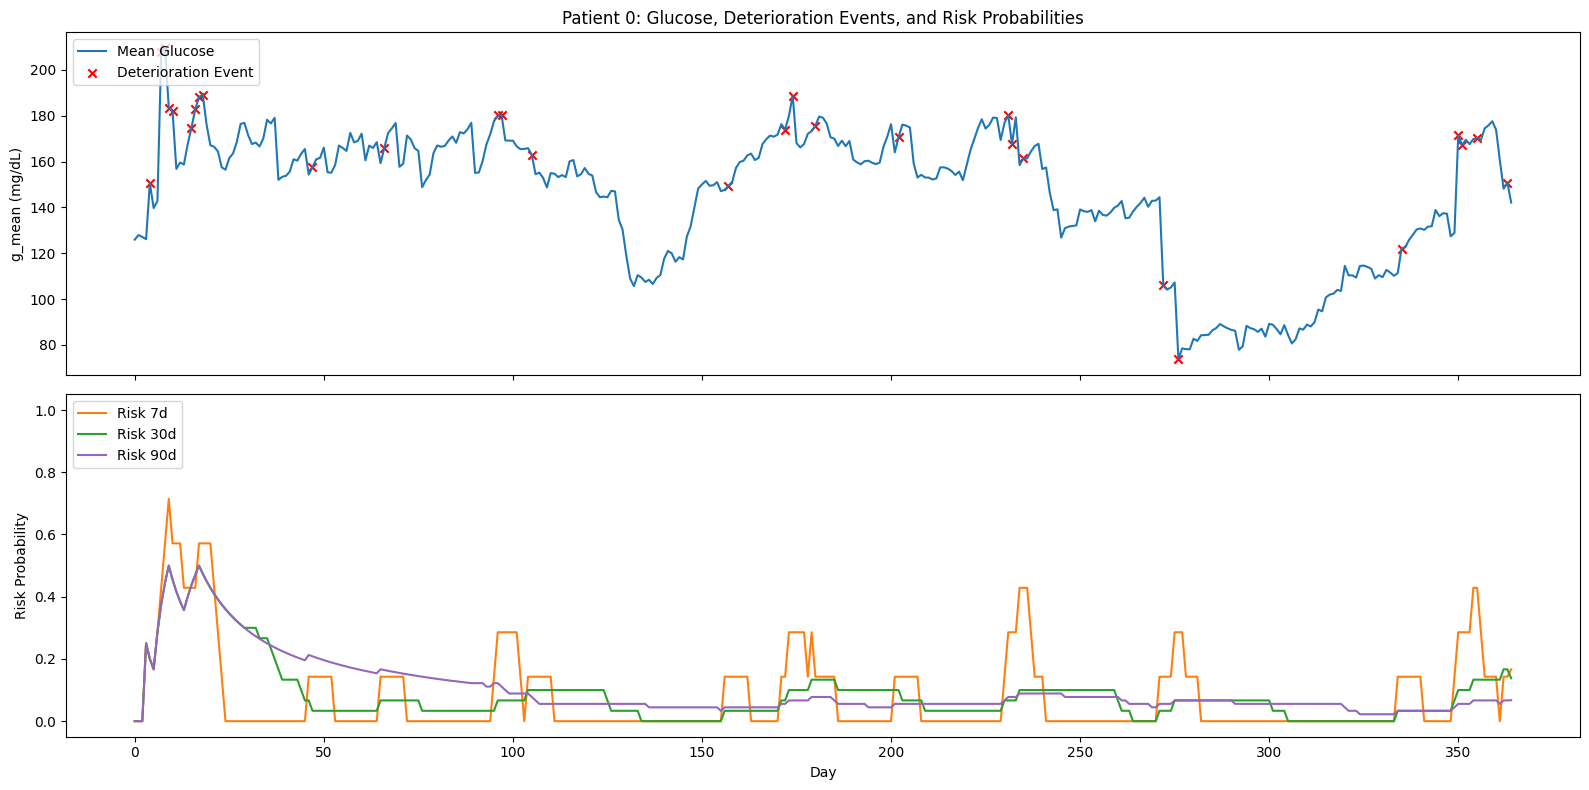

In [6]:
# Visualize risk probabilities and events for a single patient
pid = 0
df_patient = df[df['patient_id'] == pid].copy()

plt.figure(figsize=(16, 8))

# Plot mean glucose
ax1 = plt.subplot(2, 1, 1)
df_patient['g_mean'].plot(ax=ax1, label='Mean Glucose', color='tab:blue')
ax1.set_ylabel('g_mean (mg/dL)')
ax1.set_title(f'Patient {pid}: Glucose, Deterioration Events, and Risk Probabilities')

# Mark deterioration events
ax1.scatter(df_patient.index[df_patient['deterioration'] == 1],
            df_patient['g_mean'][df_patient['deterioration'] == 1],
            color='red', label='Deterioration Event', marker='x')
ax1.legend(loc='upper left')

# Plot risk probabilities
ax2 = plt.subplot(2, 1, 2, sharex=ax1)
df_patient['risk_7d_prob'].plot(ax=ax2, label='Risk 7d', color='tab:orange')
df_patient['risk_30d_prob'].plot(ax=ax2, label='Risk 30d', color='tab:green')
df_patient['risk_90d_prob'].plot(ax=ax2, label='Risk 90d', color='tab:purple')
ax2.set_ylabel('Risk Probability')
ax2.set_xlabel('Day')
ax2.set_ylim(-0.05, 1.05)
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()


In [7]:
# --- Feature Engineering: Lags, Trends, Context, Event Markers ---

# Glucose lag features
df['g_mean_lag1'] = df.groupby('patient_id')['g_mean'].shift(1)
df['g_mean_7d_mean'] = df.groupby('patient_id')['g_mean'].transform(lambda x: x.rolling(window=7, min_periods=1).mean())
df['g_mean_14d_std'] = df.groupby('patient_id')['g_mean'].transform(lambda x: x.rolling(window=14, min_periods=1).std())

# Insulin lag features
df['insulin_dose_lag1'] = df.groupby('patient_id')['insulin_dose'].shift(1)
df['insulin_dose_lag2'] = df.groupby('patient_id')['insulin_dose'].shift(2)
df['insulin_dose_lag3'] = df.groupby('patient_id')['insulin_dose'].shift(3)
df['insulin_adherence_7d_mean'] = df.groupby('patient_id')['insulin_adherence'].transform(lambda x: x.rolling(window=7, min_periods=1).mean())

# Trend windows (rolling averages)
df['g_mean_14d_mean'] = df.groupby('patient_id')['g_mean'].transform(lambda x: x.rolling(window=14, min_periods=1).mean())
df['g_mean_30d_mean'] = df.groupby('patient_id')['g_mean'].transform(lambda x: x.rolling(window=30, min_periods=1).mean())

# Regime/context features
df['weekday'] = df['date'].dt.weekday
df['is_weekend'] = df['weekday'] >= 5

# Event markers: hypo/hyper episodes in past 7 days
df['hypo_past7d'] = df.groupby('patient_id')['g_mean'].transform(lambda x: x.rolling(window=7, min_periods=1).apply(lambda y: (y < 70).sum()))
df['hyper_past7d'] = df.groupby('patient_id')['g_mean'].transform(lambda x: x.rolling(window=7, min_periods=1).apply(lambda y: (y > 180).sum()))

# Show a sample
print(df[['patient_id', 'date', 'g_mean', 'g_mean_lag1', 'g_mean_7d_mean', 'g_mean_14d_std',
         'insulin_dose_lag1', 'insulin_dose_lag2', 'insulin_dose_lag3', 'insulin_adherence_7d_mean',
         'g_mean_14d_mean', 'g_mean_30d_mean', 'is_weekend', 'hypo_past7d', 'hyper_past7d']].head(10))


   patient_id       date      g_mean  g_mean_lag1  g_mean_7d_mean  \
0           0 2020-01-01  125.925263          NaN      125.925263   
1           0 2020-01-02  127.932682   125.925263      126.928972   
2           0 2020-01-03  127.114117   127.932682      126.990687   
3           0 2020-01-04  126.137723   127.114117      126.777446   
4           0 2020-01-05  150.609984   126.137723      131.543954   
5           0 2020-01-06  139.703488   150.609984      132.903876   
6           0 2020-01-07  142.799487   139.703488      134.317535   
7           0 2020-01-08  207.624718   142.799487      145.988885   
8           0 2020-01-09  209.602056   207.624718      157.655939   
9           0 2020-01-10  183.564164   209.602056      165.720231   

   g_mean_14d_std  insulin_dose_lag1  insulin_dose_lag2  insulin_dose_lag3  \
0             NaN                NaN                NaN                NaN   
1        1.419460          53.993554                NaN                NaN   
2     

In [8]:
# --- Handle Missing Values & NaNs ---

# 1. Create missingness indicator columns for key lag features
lag_cols = ["g_mean_lag1", "insulin_dose_lag1", "insulin_dose_lag2", "insulin_dose_lag3", "g_mean_14d_std"]
for col in lag_cols:
    df[f"{col}_missing"] = df[col].isna().astype(int)

# 2. Fill missing values
# Forward-fill within each patient, then fallback to 0
df[lag_cols] = df.groupby("patient_id")[lag_cols].ffill().fillna(0)

# 3. Rolling means/std can have NaN for the first few days → backfill or use patient-level mean
rolling_cols = ["g_mean_7d_mean", "g_mean_14d_mean", "g_mean_30d_mean", "insulin_adherence_7d_mean"]
for col in rolling_cols:
    df[col] = df.groupby("patient_id")[col].transform(lambda x: x.fillna(x.mean()))
    df[col] = df[col].fillna(df[col].mean())  # global fallback

# 4. Replace any leftover NaN/Inf with safe defaults
df = df.replace([np.inf, -np.inf], np.nan)
df = df.fillna(0)

# 5. Final check
print("✅ Missing value handling complete!")
print(df.isna().sum()[df.isna().sum() > 0])


✅ Missing value handling complete!
Series([], dtype: int64)


In [9]:
# --- TFT Data Preparation: Time Series Formatting with GPU Support ---

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Define TFT parameters
MAX_ENCODER_LENGTH = 60   # 60 days of history
MAX_PREDICTION_LENGTH = 90  # 90 days ahead
QUANTILES = [0.1, 0.5, 0.9]  # 10th, 50th, 90th percentiles

# Pick device
device = torch.device("mps" if torch.mps.is_available() else "cpu")
print(f"Using device: {device}")

def prepare_tft_data(df, max_encoder_length=MAX_ENCODER_LENGTH, max_prediction_length=MAX_PREDICTION_LENGTH):
    """
    Prepare data for TFT model with proper time series formatting (CPU tensors).
    """
    # Define feature groups
    time_varying_known_features = ['weekday', 'is_weekend']
    time_varying_unknown_features = [
        'g_mean', 'g_std', 'insulin_dose', 'insulin_adherence',
        'sleep_quality', 'exercise_flag', 'meal_variability',
        'stress_index', 'illness_flag', 'missed_insulin',
        'g_mean_lag1', 'g_mean_7d_mean', 'g_mean_14d_std',
        'insulin_dose_lag1', 'insulin_dose_lag2', 'insulin_dose_lag3',
        'insulin_adherence_7d_mean', 'g_mean_14d_mean', 'g_mean_30d_mean',
        'hypo_past7d', 'hyper_past7d'
    ]
    static_features = ['patient_id']
    target = 'g_mean'

    # Encode patient_id as categorical index
    df = df.copy()
    df['patient_id'] = df['patient_id'].astype("category").cat.codes

    # Ensure all features are numeric
    for col in time_varying_known_features + time_varying_unknown_features + [target]:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    sequences = []

    for pid in df['patient_id'].unique():
        patient_data = df[df['patient_id'] == pid].sort_values('date').reset_index(drop=True)

        if len(patient_data) < max_encoder_length + max_prediction_length:
            continue

        for i in range(max_encoder_length, len(patient_data) - max_prediction_length + 1):
            encoder_start = i - max_encoder_length
            encoder_end = i
            decoder_start = i
            decoder_end = i + max_prediction_length

            encoder_known = patient_data[time_varying_known_features].iloc[encoder_start:encoder_end].astype(float).values
            encoder_unknown = patient_data[time_varying_unknown_features].iloc[encoder_start:encoder_end].astype(float).values
            decoder_known = patient_data[time_varying_known_features].iloc[decoder_start:decoder_end].astype(float).values
            target_values = patient_data[target].iloc[decoder_start:decoder_end].astype(float).values
            static_vals = np.array([pid])

            # ✅ keep tensors on CPU
            sequences.append({
                'encoder_known': torch.tensor(encoder_known, dtype=torch.float32),
                'encoder_unknown': torch.tensor(encoder_unknown, dtype=torch.float32),
                'decoder_known': torch.tensor(decoder_known, dtype=torch.float32),
                'static': torch.tensor(static_vals, dtype=torch.long),
                'target': torch.tensor(target_values, dtype=torch.float32)
            })

    return sequences, time_varying_known_features, time_varying_unknown_features, static_features

# Prepare the data
print("Preparing TFT data...")
sequences, tv_known, tv_unknown, static = prepare_tft_data(df)
print(f"Created {len(sequences)} sequences")
print(f"Time-varying known features: {tv_known}")
print(f"Time-varying unknown features: {tv_unknown}")
print(f"Static features: {static}")


Using device: mps
Preparing TFT data...
Created 216000 sequences
Time-varying known features: ['weekday', 'is_weekend']
Time-varying unknown features: ['g_mean', 'g_std', 'insulin_dose', 'insulin_adherence', 'sleep_quality', 'exercise_flag', 'meal_variability', 'stress_index', 'illness_flag', 'missed_insulin', 'g_mean_lag1', 'g_mean_7d_mean', 'g_mean_14d_std', 'insulin_dose_lag1', 'insulin_dose_lag2', 'insulin_dose_lag3', 'insulin_adherence_7d_mean', 'g_mean_14d_mean', 'g_mean_30d_mean', 'hypo_past7d', 'hyper_past7d']
Static features: ['patient_id']


In [10]:
# --- TFT Dataset + Model (Optimized) ---

import torch
import torch.nn as nn
from torch.utils.data import Dataset
import numpy as np
from sklearn.preprocessing import StandardScaler

# --- TFT Dataset ---
class TFTDataset(Dataset):
    """Optimized Dataset class for TFT model"""
    def __init__(self, sequences, scalers=None, fit_scalers=True):
        self.sequences = sequences

        if fit_scalers:
            self.scalers = self._fit_scalers()
            self._apply_scaling()
        else:
            self.scalers = scalers
            self._apply_scaling()

    def _fit_scalers(self):
        scalers = {}
        encoder_unknown_data = []
        target_data = []

        for seq in self.sequences:
            encoder_unknown_data.append(seq['encoder_unknown'])
            target_data.append(seq['target'])

        scalers['encoder_unknown'] = StandardScaler()
        scalers['target'] = StandardScaler()

        encoder_flat = np.vstack(encoder_unknown_data)
        target_flat = np.concatenate(target_data)

        scalers['encoder_unknown'].fit(encoder_flat)
        scalers['target'].fit(target_flat.reshape(-1, 1))

        return scalers

    def _apply_scaling(self):
        for seq in self.sequences:
            seq['encoder_unknown'] = self.scalers['encoder_unknown'].transform(seq['encoder_unknown'])
            seq['target'] = self.scalers['target'].transform(seq['target'].reshape(-1, 1)).flatten()

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = self.sequences[idx]

        return {
            'encoder_known': torch.tensor(seq['encoder_known'], dtype=torch.float32),
            'encoder_unknown': torch.tensor(seq['encoder_unknown'], dtype=torch.float32),
            'decoder_known': torch.tensor(seq['decoder_known'], dtype=torch.float32),
            'static': torch.tensor(seq['static'], dtype=torch.long),  # categorical for embedding
            'target': torch.tensor(seq['target'], dtype=torch.float32)
        }

# --- TFT Model ---
class TemporalFusionTransformer(nn.Module):
    """Simplified TFT implementation for glucose forecasting (fixed output shapes)."""

    def __init__(self,
                 encoder_length=60,
                 prediction_length=90,
                 n_encoder_known=2,
                 n_encoder_unknown=20,
                 n_decoder_known=2,
                 n_static=100,       # number of unique static categories (patients)
                 hidden_size=64,
                 n_heads=4,
                 n_layers=2,
                 dropout=0.1,
                 n_quantiles=3):
        super().__init__()

        self.encoder_length = encoder_length
        self.prediction_length = prediction_length
        self.hidden_size = hidden_size
        self.n_quantiles = n_quantiles

        # Input projections (project each time-step's features into hidden space)
        self.encoder_known_proj = nn.Linear(n_encoder_known, hidden_size)
        self.encoder_unknown_proj = nn.Linear(n_encoder_unknown, hidden_size)
        self.decoder_known_proj = nn.Linear(n_decoder_known, hidden_size)

        # Static embedding (patient_id, demographics, etc.)
        self.static_embedding = nn.Embedding(n_static, hidden_size)

        # Variable selection for encoder
        # input dim = (enc_known_proj + enc_unknown_proj) + static = hidden + hidden + hidden = hidden*3
        self.var_select_encoder = nn.Sequential(
            nn.Linear(hidden_size * 3, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 2),
            nn.Softmax(dim=-1)
        )

        # LSTMs
        self.encoder_lstm = nn.LSTM(hidden_size, hidden_size, n_layers,
                                   batch_first=True, dropout=dropout)
        self.decoder_lstm = nn.LSTM(hidden_size, hidden_size, n_layers,
                                   batch_first=True, dropout=dropout)

        # Attention (batch_first=True)
        self.attention = nn.MultiheadAttention(hidden_size, n_heads,
                                               dropout=dropout, batch_first=True)

        # Output: map hidden_size -> n_quantiles **per timestep**
        self.output_layer = nn.Linear(hidden_size, n_quantiles)

        self.dropout = nn.Dropout(dropout)

    def forward(self, encoder_known, encoder_unknown, decoder_known, static):
        """
        encoder_known:  (B, encoder_length, n_encoder_known)
        encoder_unknown:(B, encoder_length, n_encoder_unknown)
        decoder_known:  (B, prediction_length, n_decoder_known)
        static:         (B, 1)  (LongTensor categorical indices)

        returns:
          output (B, prediction_length, n_quantiles)
        """
        batch_size = encoder_known.size(0)

        # Project inputs into hidden space per time-step
        enc_known_proj = self.encoder_known_proj(encoder_known)          # (B, enc_len, hidden)
        enc_unknown_proj = self.encoder_unknown_proj(encoder_unknown)    # (B, enc_len, hidden)
        dec_known_proj = self.decoder_known_proj(decoder_known)          # (B, pred_len, hidden)

        # Static embedding -> (B, hidden)
        static_proj = self.static_embedding(static.view(-1)).unsqueeze(1)  # (B, 1, hidden)
        static_exp_enc = static_proj.expand(-1, self.encoder_length, -1)   # (B, enc_len, hidden)

        # Variable selection input
        enc_combined = torch.cat([enc_known_proj, enc_unknown_proj, static_exp_enc], dim=-1)  # (B, enc_len, hidden*3)
        var_weights = self.var_select_encoder(enc_combined)  # (B, enc_len, 2)

        # Apply variable selection: produce a weighted combination of known/unknown projections
        w_known = var_weights[..., 0:1]   # (B, enc_len, 1)
        w_unknown = var_weights[..., 1:2] # (B, enc_len, 1)
        enc_selected = w_known * enc_known_proj + w_unknown * enc_unknown_proj   # (B, enc_len, hidden)

        # Encoder LSTM -> enc_output: (B, enc_len, hidden)
        enc_output, (enc_hidden, enc_cell) = self.encoder_lstm(enc_selected)

        # Prepare decoder initial hidden using encoder hidden (LSTM states)
        # dec_known_proj is (B, pred_len, hidden)
        dec_output, _ = self.decoder_lstm(dec_known_proj, (enc_hidden, enc_cell))

        # Attention: queries=decoder, keys=encoder, values=encoder
        attn_output, _ = self.attention(dec_output, enc_output, enc_output)  # (B, pred_len, hidden)

        # Combine with static projected into decoder time dimension
        static_exp_dec = static_proj.expand(-1, self.prediction_length, -1)   # (B, pred_len, hidden)
        combined = attn_output + static_exp_dec
        combined = self.dropout(combined)  # (B, pred_len, hidden)

        # Final per-timestep quantile output
        # Apply linear to the last dim — this yields (B, pred_len, n_quantiles)
        output = self.output_layer(combined)

        # Sanity check during dev (can remove in production)
        assert output.shape == (batch_size, self.prediction_length, self.n_quantiles), \
            f"Output shape mismatch: {output.shape} expected {(batch_size, self.prediction_length, self.n_quantiles)}"

        return output


model = TemporalFusionTransformer(
    encoder_length=MAX_ENCODER_LENGTH,
    prediction_length=MAX_PREDICTION_LENGTH,
    n_encoder_known=len(tv_known),
    n_encoder_unknown=len(tv_unknown),
    n_decoder_known=len(tv_known),
    n_static=df['patient_id'].nunique(),  # dynamic embedding size
    hidden_size=64,
    n_heads=4,
    n_layers=2,
    dropout=0.1,
    n_quantiles=len(QUANTILES)
)

print(f"TFT Model initialized with {sum(p.numel() for p in model.parameters()):,} parameters")



TFT Model initialized with 228,229 parameters


In [11]:
# --- TFT Training and Evaluation (Optimized + Early Stopping) ---

import os
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm
import glob

def quantile_loss(pred, target, quantiles):
    """Quantile loss for probabilistic forecasting"""
    losses = []
    for i, q in enumerate(quantiles):
        error = target - pred[:, :, i]
        loss = torch.max((q - 1) * error, q * error)
        losses.append(loss)
    return torch.stack(losses, dim=-1).mean()

def save_model_and_scalers(model, scalers, train_losses, val_losses, model_path='tft_model.pth', scalers_path='tft_scalers.pkl'):
    """Save trained model and scalers"""
    os.makedirs('models', exist_ok=True)

    torch.save(model.state_dict(), os.path.join('models', model_path))

    with open(os.path.join('models', scalers_path), 'wb') as f:
        pickle.dump(scalers, f)

    print(f"✅ Model saved to: models/{model_path}")
    print(f"✅ Scalers saved to: models/{scalers_path}")

def load_model_and_scalers(model_class, model_config, model_path='models/tft_model.pth', scalers_path='models/tft_scalers.pkl'):
    """Load trained model and scalers"""
    model = model_class(**model_config)
    model.load_state_dict(torch.load(model_path, map_location='cpu'))

    with open(scalers_path, 'rb') as f:
        scalers = pickle.load(f)

    return model, scalers



def train_tft(model, train_loader, val_loader, epochs=50, lr=0.001, save_model=True,
              grad_clip=1.0, patience=10, resume_from=None, max_checkpoints=5):
    """
    Train TFT model with AMP, gradient clipping, early stopping, progress bars,
    and checkpoint rotation (keep only last N).
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    scaler = GradScaler()

    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    patience_counter = 0
    start_epoch = 1

    # 🔄 Resume from checkpoint if provided
    if resume_from and os.path.exists(resume_from):
        print(f"♻️ Resuming from checkpoint: {resume_from}")
        checkpoint = torch.load(resume_from, map_location=device)
        model.load_state_dict(checkpoint['model_state'])
        optimizer.load_state_dict(checkpoint['optimizer_state'])
        scaler.load_state_dict(checkpoint['scaler_state'])
        train_losses = checkpoint['train_losses']
        val_losses = checkpoint['val_losses']
        best_val_loss = checkpoint['best_val_loss']
        patience_counter = checkpoint['patience_counter']
        start_epoch = checkpoint['epoch'] + 1

    checkpoint_dir = "models/checkpoints"
    os.makedirs(checkpoint_dir, exist_ok=True)

    for epoch in range(start_epoch, epochs + 1):
        # --- Training ---
        model.train()
        total_train_loss = 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs} [Train]", leave=False)
        for batch in pbar:
            batch = {k: v.to(device) for k, v in batch.items()}
            optimizer.zero_grad()

            with autocast():
                pred = model(batch['encoder_known'], batch['encoder_unknown'],
                             batch['decoder_known'], batch['static'])
                loss = quantile_loss(pred, batch['target'], QUANTILES)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer)
            scaler.update()

            total_train_loss += loss.item()
            pbar.set_postfix(loss=loss.item())

        avg_train_loss = total_train_loss / len(train_loader)

        # --- Validation ---
        model.eval()
        total_val_loss = 0
        vbar = tqdm(val_loader, desc=f"Epoch {epoch}/{epochs} [Val]", leave=False)
        with torch.no_grad(), autocast():
            for batch in vbar:
                batch = {k: v.to(device) for k, v in batch.items()}
                pred = model(batch['encoder_known'], batch['encoder_unknown'],
                             batch['decoder_known'], batch['static'])
                loss = quantile_loss(pred, batch['target'], QUANTILES)
                total_val_loss += loss.item()
                vbar.set_postfix(loss=loss.item())

        avg_val_loss = total_val_loss / len(val_loader)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        # --- Scheduler + Early Stopping ---
        scheduler.step(avg_val_loss)
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            if save_model:
                save_model_and_scalers(model, train_dataset.scalers,
                                       train_losses, val_losses)
        else:
            patience_counter += 1

        # --- Save checkpoint ---
        ckpt_path = os.path.join(checkpoint_dir, f"tft_epoch{epoch}.pth")
        torch.save({
            'epoch': epoch,
            'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'scaler_state': scaler.state_dict(),
            'train_losses': train_losses,
            'val_losses': val_losses,
            'best_val_loss': best_val_loss,
            'patience_counter': patience_counter,
            'scalers': train_dataset.scalers
        }, ckpt_path)
        print(f"💾 Checkpoint saved: {ckpt_path}")

        # --- Rotate old checkpoints ---
        ckpts = sorted(glob.glob(os.path.join(checkpoint_dir, "tft_epoch*.pth")),
                       key=os.path.getmtime)
        if len(ckpts) > max_checkpoints:
            to_delete = ckpts[:-max_checkpoints]
            for old_ckpt in to_delete:
                os.remove(old_ckpt)
                print(f"🗑️ Deleted old checkpoint: {old_ckpt}")

        print(f"✅ Epoch {epoch:03d} | Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | Patience {patience_counter}/{patience}")

        if patience_counter >= patience:
            print("⏹️ Early stopping triggered!")
            break

    return train_losses, val_losses

# --- Data Prep ---
train_sequences, val_sequences = train_test_split(sequences, test_size=0.2, random_state=42)
train_dataset = TFTDataset(train_sequences, fit_scalers=True)
val_dataset = TFTDataset(val_sequences, scalers=train_dataset.scalers, fit_scalers=False)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

print(f"Training sequences: {len(train_sequences)} | Validation sequences: {len(val_sequences)}")

# # --- Train ---
# print("🚀 Training TFT model with AMP + Early Stopping...")
# train_losses, val_losses = train_tft(model, train_loader, val_loader, epochs=50, lr=0.001, patience=10)


Training sequences: 172800 | Validation sequences: 43200


In [12]:
import torch
from sklearn.preprocessing import StandardScaler

# --- Paths ---
checkpoint_path = "tft_epoch50.pth"  # Replace XX with your epoch number

# --- Recreate the model ---
model = TemporalFusionTransformer(
    encoder_length=MAX_ENCODER_LENGTH,
    prediction_length=MAX_PREDICTION_LENGTH,
    n_encoder_known=len(tv_known),
    n_encoder_unknown=len(tv_unknown),
    n_decoder_known=len(tv_known),
    n_static=df['patient_id'].nunique(),
    hidden_size=64,
    n_heads=4,
    n_layers=2,
    dropout=0.1,
    n_quantiles=len(QUANTILES)
)

# --- Load checkpoint safely ---
with torch.serialization.safe_globals([StandardScaler]):
    ckpt = torch.load(checkpoint_path, weights_only=False, map_location=torch.device('mps'))

# --- Load model weights ---
model.load_state_dict(ckpt['model_state'])
model.eval()  # Set to evaluation mode

# --- Load scalers and training history ---
scalers = ckpt['scalers']
train_losses = ckpt['train_losses']
val_losses = ckpt['val_losses']

print("✅ Model, scalers, and training history loaded successfully!")


✅ Model, scalers, and training history loaded successfully!


/Users/raazifaisal/Documents/MedicalPrediction/.venv/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Evaluating TFT model with comprehensive metrics...


/Users/raazifaisal/Documents/MedicalPrediction/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/var/folders/zv/k_988svd3d5cdwzmb395b9vh0000gn/T/ipykernel_85398/652350536.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'encoder_known': torch.tensor(seq['encoder_known'], dtype=torch.float32),
/var/folders/zv/k_988svd3d5cdwzmb395b9vh0000gn/T/ipykernel_85398/652350536.py:56: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'decoder_known': torch.tensor(seq['decoder_known'], dtype=torch.float32),
/var/folders/zv/k_988svd3d5

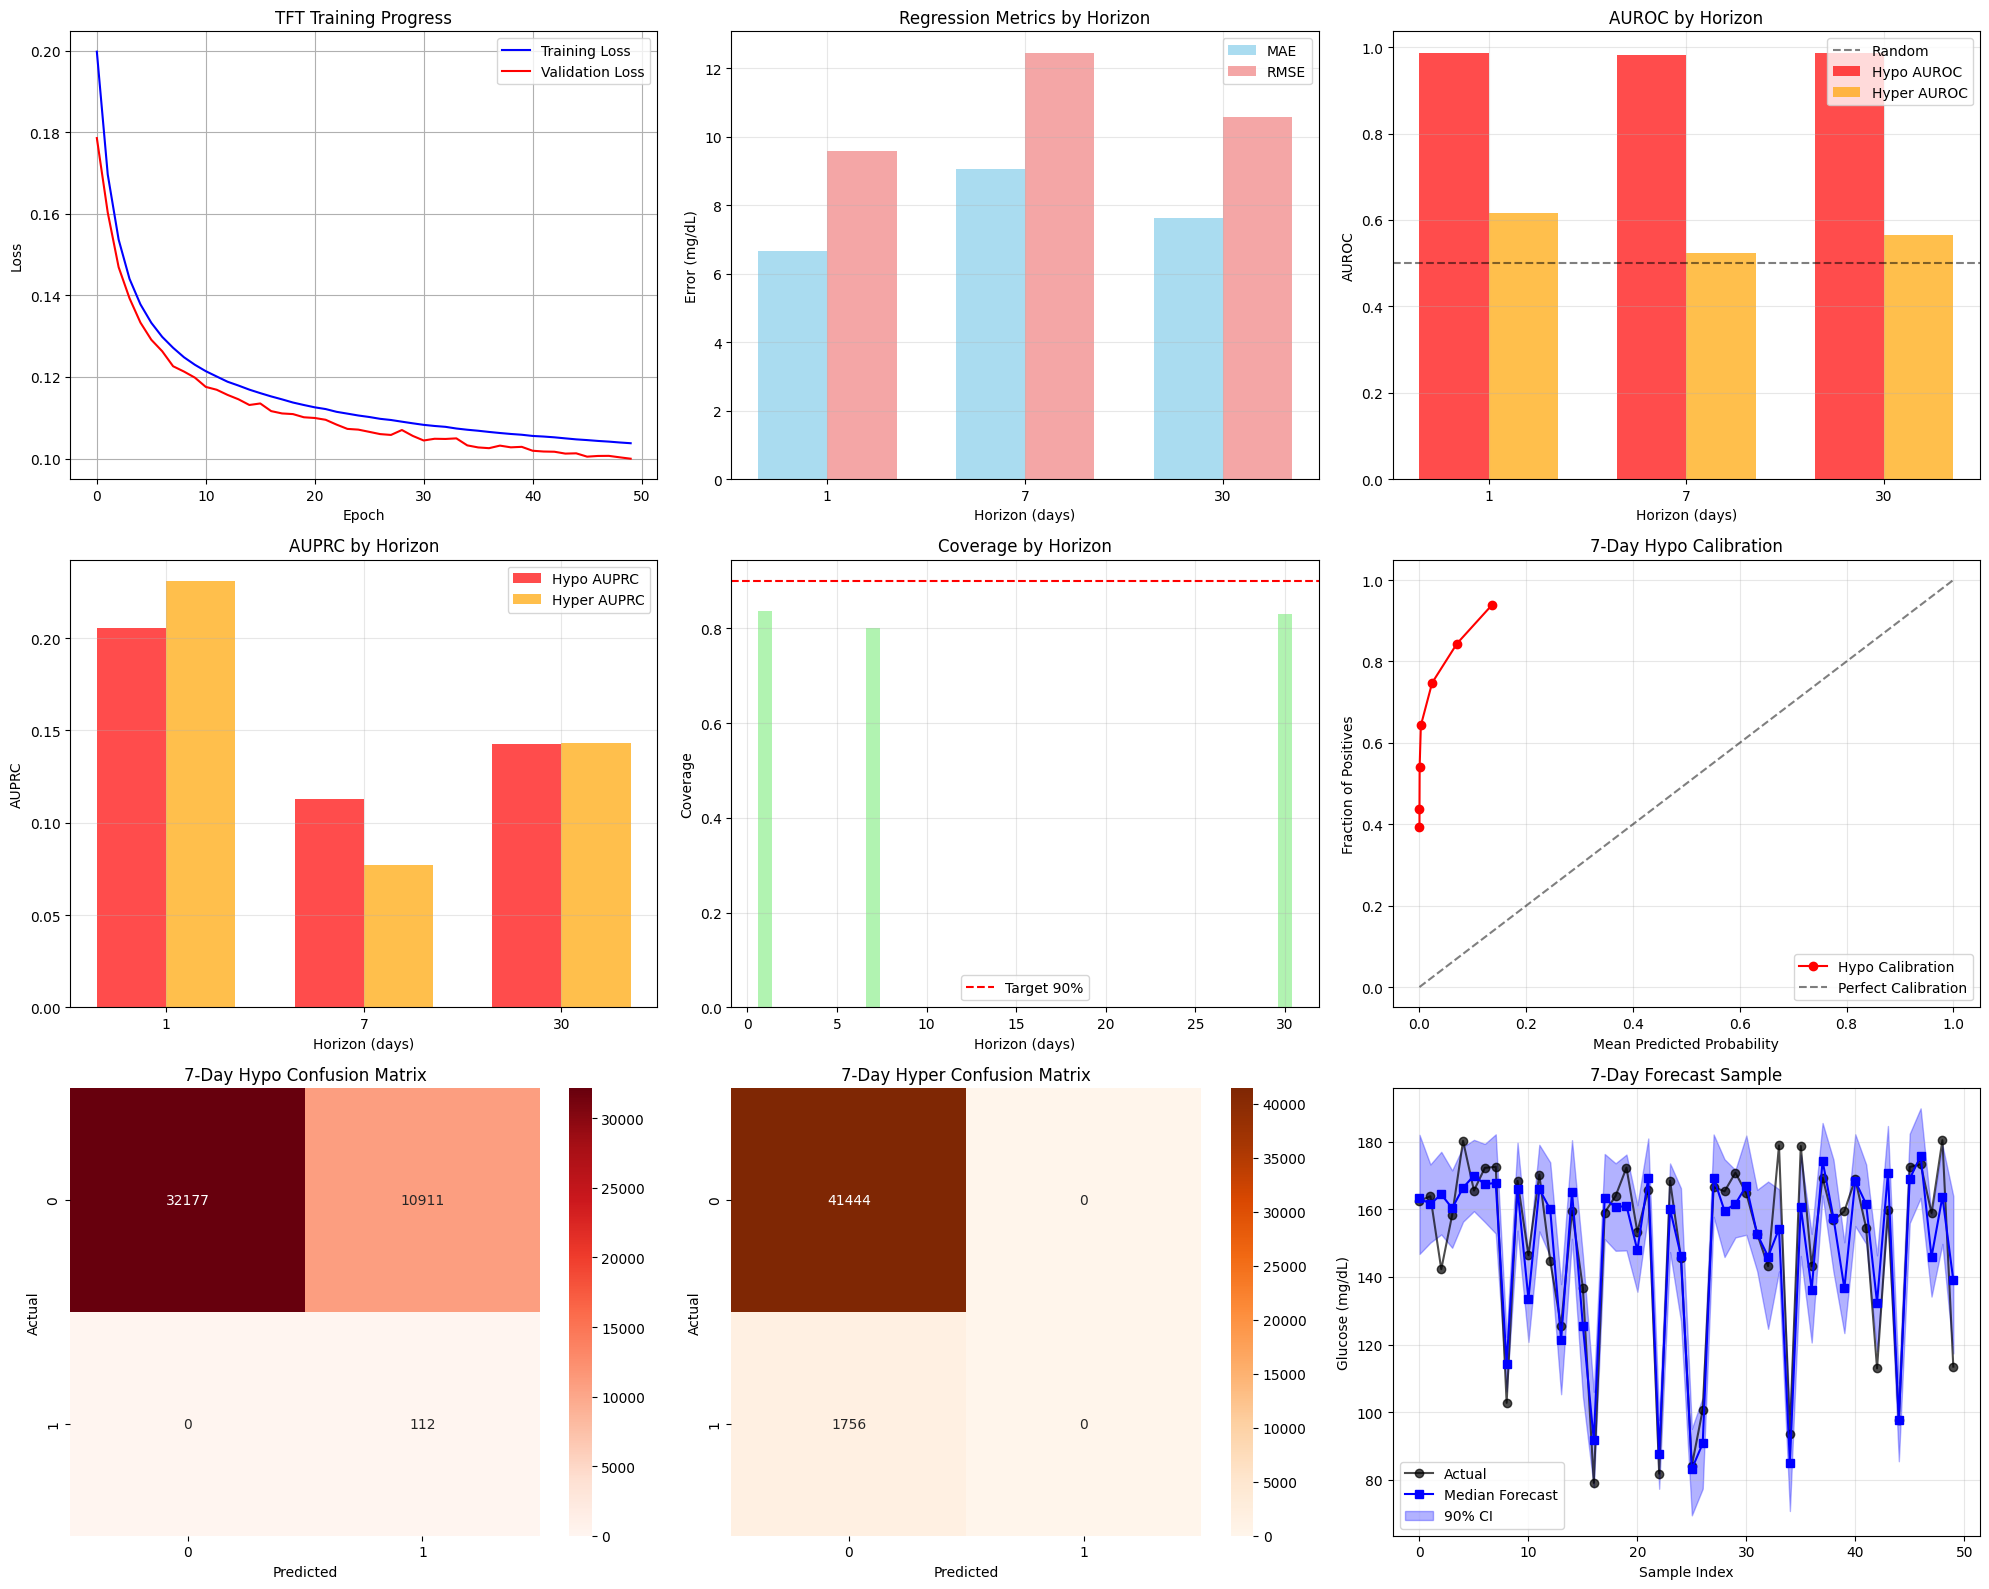

\n================================================================================
COMPREHENSIVE TFT EVALUATION RESULTS
\nHorizon 1 days:
----------------------------------------
Regression Metrics:
  MAE: 6.65 mg/dL
  RMSE: 9.58 mg/dL
  MAPE: 4.56%
  Coverage: 0.838
\nClinical Event Detection:
  Hypoglycemia AUROC: 0.988
  Hypoglycemia AUPRC: 0.205
  Hyperglycemia AUROC: 0.617
  Hyperglycemia AUPRC: 0.231
\nConfusion Matrices (threshold=0.5):
  Hypo CM: [[31508, 11583], [0, 109]]
  Hyper CM: [[41368, 0], [1832, 0]]
\nHorizon 7 days:
----------------------------------------
Regression Metrics:
  MAE: 9.06 mg/dL
  RMSE: 12.46 mg/dL
  MAPE: 6.28%
  Coverage: 0.802
\nClinical Event Detection:
  Hypoglycemia AUROC: 0.982
  Hypoglycemia AUPRC: 0.113
  Hyperglycemia AUROC: 0.524
  Hyperglycemia AUPRC: 0.077
\nConfusion Matrices (threshold=0.5):
  Hypo CM: [[32177, 10911], [0, 112]]
  Hyper CM: [[41444, 0], [1756, 0]]
\nHorizon 30 days:
----------------------------------------
Regression Metr

In [13]:
# --- TFT Comprehensive Evaluation with Clinical Metrics ---
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix
from sklearn.calibration import calibration_curve
from matplotlib import pyplot as plt
import seaborn as sns   

def evaluate_tft_comprehensive(model, test_loader, scalers, horizons=[1, 7, 30]):
    """Comprehensive evaluation with AUROC, AUPRC, calibration, and confusion matrix"""
    device = torch.device('mps' if torch.mps.is_available() else 'cpu')
    model = model.to(device)
    model.eval()
    predictions = []
    targets = []

    with torch.no_grad():
        for batch in test_loader:
            encoder_known = batch['encoder_known'].to(device)
            encoder_unknown = batch['encoder_unknown'].to(device)
            decoder_known = batch['decoder_known'].to(device)
            static = batch['static'].to(device)
            target = batch['target'].to(device)

            pred = model(encoder_known, encoder_unknown, decoder_known, static)

            # Denormalize predictions
            pred_denorm = scalers['target'].inverse_transform(
                pred.cpu().numpy().reshape(-1, 1)
            ).reshape(pred.shape)

            # Denormalize targets
            target_denorm = scalers['target'].inverse_transform(
                target.cpu().numpy().reshape(-1, 1)
            ).reshape(target.shape)

            predictions.append(pred_denorm)
            targets.append(target_denorm)

    predictions = np.concatenate(predictions, axis=0)
    targets = np.concatenate(targets, axis=0)

    # Calculate comprehensive metrics for each horizon
    results = {}
    for h in horizons:
        if h <= predictions.shape[1]:
            # Get predictions and targets for horizon h
            pred_h = predictions[:, h-1, :]  # Shape: (batch, quantiles)
            target_h = targets[:, h-1]       # Shape: (batch,)

            # Basic regression metrics
            mae = np.mean(np.abs(pred_h[:, 1] - target_h))  # Median prediction
            mape = np.mean(np.abs((pred_h[:, 1] - target_h) / target_h)) * 100
            rmse = np.sqrt(np.mean((pred_h[:, 1] - target_h) ** 2))

            # Coverage (90% confidence interval)
            lower = pred_h[:, 0]  # 10th percentile
            upper = pred_h[:, 2]  # 90th percentile
            coverage = np.mean((target_h >= lower) & (target_h <= upper))

            # Clinical event classification
            # Hypoglycemia events (< 70 mg/dL)
            hypo_actual = (target_h < 70).astype(int)
            hypo_prob = 1 - (pred_h[:, 1] - 70) / (pred_h[:, 1] + 1e-8)  # Probability of hypo
            hypo_prob = np.clip(hypo_prob, 0, 1)

            # Hyperglycemia events (> 180 mg/dL)
            hyper_actual = (target_h > 180).astype(int)
            hyper_prob = (pred_h[:, 1] - 180) / (pred_h[:, 1] + 1e-8)  # Probability of hyper
            hyper_prob = np.clip(hyper_prob, 0, 1)

            # Calculate AUROC and AUPRC for hypo events
            hypo_auroc = roc_auc_score(hypo_actual, hypo_prob) if len(np.unique(hypo_actual)) > 1 else 0.5
            hypo_auprc = average_precision_score(hypo_actual, hypo_prob) if len(np.unique(hypo_actual)) > 1 else np.mean(hypo_actual)

            # Calculate AUROC and AUPRC for hyper events
            hyper_auroc = roc_auc_score(hyper_actual, hyper_prob) if len(np.unique(hyper_actual)) > 1 else 0.5
            hyper_auprc = average_precision_score(hyper_actual, hyper_prob) if len(np.unique(hyper_actual)) > 1 else np.mean(hyper_actual)

            # Calibration for hypo events
            hypo_calibration = calibration_curve(hypo_actual, hypo_prob, n_bins=10) if len(np.unique(hypo_actual)) > 1 else (np.array([0.5]), np.array([0.5]))

            # Calibration for hyper events
            hyper_calibration = calibration_curve(hyper_actual, hyper_prob, n_bins=10) if len(np.unique(hyper_actual)) > 1 else (np.array([0.5]), np.array([0.5]))

            # Confusion matrices (using 0.5 threshold)
            hypo_pred_binary = (hypo_prob > 0.5).astype(int)
            hyper_pred_binary = (hyper_prob > 0.5).astype(int)

            hypo_cm = confusion_matrix(hypo_actual, hypo_pred_binary)
            hyper_cm = confusion_matrix(hyper_actual, hyper_pred_binary)

            results[h] = {
                # Regression metrics
                'mae': mae,
                'mape': mape,
                'rmse': rmse,
                'coverage': coverage,

                # Clinical event metrics
                'hypo_auroc': hypo_auroc,
                'hypo_auprc': hypo_auprc,
                'hyper_auroc': hyper_auroc,
                'hyper_auprc': hyper_auprc,

                # Calibration
                'hypo_calibration': hypo_calibration,
                'hyper_calibration': hyper_calibration,

                # Confusion matrices
                'hypo_cm': hypo_cm,
                'hyper_cm': hyper_cm,

                # Raw data for plotting
                'predictions': pred_h,
                'targets': target_h,
                'hypo_actual': hypo_actual,
                'hypo_prob': hypo_prob,
                'hyper_actual': hyper_actual,
                'hyper_prob': hyper_prob
            }

    return results

def plot_comprehensive_evaluation(results, train_losses, val_losses):
    """Plot comprehensive evaluation results"""
    fig, axes = plt.subplots(3, 3, figsize=(20, 16))

    # Plot 1: Training/Validation Loss
    axes[0, 0].plot(train_losses, label='Training Loss', color='blue')
    axes[0, 0].plot(val_losses, label='Validation Loss', color='red')
    axes[0, 0].set_title('TFT Training Progress')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    # Plot 2: Regression Metrics by Horizon
    horizons = list(results.keys())
    maes = [results[h]['mae'] for h in horizons]
    rmses = [results[h]['rmse'] for h in horizons]

    x = np.arange(len(horizons))
    width = 0.35
    axes[0, 1].bar(x - width/2, maes, width, label='MAE', color='skyblue', alpha=0.7)
    axes[0, 1].bar(x + width/2, rmses, width, label='RMSE', color='lightcoral', alpha=0.7)
    axes[0, 1].set_title('Regression Metrics by Horizon')
    axes[0, 1].set_xlabel('Horizon (days)')
    axes[0, 1].set_ylabel('Error (mg/dL)')
    axes[0, 1].set_xticks(x)
    axes[0, 1].set_xticklabels(horizons)
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Plot 3: AUROC by Horizon
    hypo_aurocs = [results[h]['hypo_auroc'] for h in horizons]
    hyper_aurocs = [results[h]['hyper_auroc'] for h in horizons]

    axes[0, 2].bar(x - width/2, hypo_aurocs, width, label='Hypo AUROC', color='red', alpha=0.7)
    axes[0, 2].bar(x + width/2, hyper_aurocs, width, label='Hyper AUROC', color='orange', alpha=0.7)
    axes[0, 2].axhline(y=0.5, color='black', linestyle='--', alpha=0.5, label='Random')
    axes[0, 2].set_title('AUROC by Horizon')
    axes[0, 2].set_xlabel('Horizon (days)')
    axes[0, 2].set_ylabel('AUROC')
    axes[0, 2].set_xticks(x)
    axes[0, 2].set_xticklabels(horizons)
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)

    # Plot 4: AUPRC by Horizon
    hypo_auprcs = [results[h]['hypo_auprc'] for h in horizons]
    hyper_auprcs = [results[h]['hyper_auprc'] for h in horizons]

    axes[1, 0].bar(x - width/2, hypo_auprcs, width, label='Hypo AUPRC', color='red', alpha=0.7)
    axes[1, 0].bar(x + width/2, hyper_auprcs, width, label='Hyper AUPRC', color='orange', alpha=0.7)
    axes[1, 0].set_title('AUPRC by Horizon')
    axes[1, 0].set_xlabel('Horizon (days)')
    axes[1, 0].set_ylabel('AUPRC')
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(horizons)
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # Plot 5: Coverage by Horizon
    coverages = [results[h]['coverage'] for h in horizons]
    axes[1, 1].bar(horizons, coverages, color='lightgreen', alpha=0.7)
    axes[1, 1].axhline(y=0.9, color='red', linestyle='--', label='Target 90%')
    axes[1, 1].set_title('Coverage by Horizon')
    axes[1, 1].set_xlabel('Horizon (days)')
    axes[1, 1].set_ylabel('Coverage')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    # Plot 6: Calibration Plot (7-day horizon)
    h = 7
    if h in results:
        hypo_cal = results[h]['hypo_calibration']
        axes[1, 2].plot(hypo_cal[0], hypo_cal[1], 'o-', label='Hypo Calibration', color='red')
        axes[1, 2].plot([0, 1], [0, 1], '--', color='black', alpha=0.5, label='Perfect Calibration')
        axes[1, 2].set_title(f'{h}-Day Hypo Calibration')
        axes[1, 2].set_xlabel('Mean Predicted Probability')
        axes[1, 2].set_ylabel('Fraction of Positives')
        axes[1, 2].legend()
        axes[1, 2].grid(True, alpha=0.3)

    # Plot 7: Confusion Matrix - Hypo (7-day)
    if h in results:
        hypo_cm = results[h]['hypo_cm']
        sns.heatmap(hypo_cm, annot=True, fmt='d', cmap='Reds', ax=axes[2, 0])
        axes[2, 0].set_title(f'{h}-Day Hypo Confusion Matrix')
        axes[2, 0].set_xlabel('Predicted')
        axes[2, 0].set_ylabel('Actual')

    # Plot 8: Confusion Matrix - Hyper (7-day)
    if h in results:
        hyper_cm = results[h]['hyper_cm']
        sns.heatmap(hyper_cm, annot=True, fmt='d', cmap='Oranges', ax=axes[2, 1])
        axes[2, 1].set_title(f'{h}-Day Hyper Confusion Matrix')
        axes[2, 1].set_xlabel('Predicted')
        axes[2, 1].set_ylabel('Actual')

    # Plot 9: Sample forecast with confidence bands
    if h in results:
        pred_h = results[h]['predictions']
        target_h = results[h]['targets']

        # Take first 50 samples for visualization
        n_samples = min(50, len(pred_h))
        x_vals = range(n_samples)

        axes[2, 2].plot(x_vals, target_h[:n_samples], 'o-', label='Actual', color='black', alpha=0.7)
        axes[2, 2].plot(x_vals, pred_h[:n_samples, 1], 's-', label='Median Forecast', color='blue')
        axes[2, 2].fill_between(x_vals, pred_h[:n_samples, 0], pred_h[:n_samples, 2],
                               alpha=0.3, color='blue', label='90% CI')
        axes[2, 2].set_title(f'{h}-Day Forecast Sample')
        axes[2, 2].set_xlabel('Sample Index')
        axes[2, 2].set_ylabel('Glucose (mg/dL)')
        axes[2, 2].legend()
        axes[2, 2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print comprehensive evaluation metrics
    print("\\n" + "="*80)
    print("COMPREHENSIVE TFT EVALUATION RESULTS")
    print("="*80)

    for h in horizons:
        r = results[h]
        print(f"\\nHorizon {h} days:")
        print("-" * 40)
        print(f"Regression Metrics:")
        print(f"  MAE: {r['mae']:.2f} mg/dL")
        print(f"  RMSE: {r['rmse']:.2f} mg/dL")
        print(f"  MAPE: {r['mape']:.2f}%")
        print(f"  Coverage: {r['coverage']:.3f}")

        print(f"\\nClinical Event Detection:")
        print(f"  Hypoglycemia AUROC: {r['hypo_auroc']:.3f}")
        print(f"  Hypoglycemia AUPRC: {r['hypo_auprc']:.3f}")
        print(f"  Hyperglycemia AUROC: {r['hyper_auroc']:.3f}")
        print(f"  Hyperglycemia AUPRC: {r['hyper_auprc']:.3f}")

        print(f"\\nConfusion Matrices (threshold=0.5):")
        print(f"  Hypo CM: {r['hypo_cm'].tolist()}")
        print(f"  Hyper CM: {r['hyper_cm'].tolist()}")

    print("\\n" + "="*80)

def plot_tft_results(results, patient_id=0):
    """Plot TFT forecasting results"""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Plot 1: Training/Validation Loss
    axes[0, 0].plot(train_losses, label='Training Loss', color='blue')
    axes[0, 0].plot(val_losses, label='Validation Loss', color='red')
    axes[0, 0].set_title('TFT Training Progress')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    # Plot 2: Horizon-wise MAE
    horizons = list(results.keys())
    maes = [results[h]['mae'] for h in horizons]
    axes[0, 1].bar(horizons, maes, color='skyblue', alpha=0.7)
    axes[0, 1].set_title('MAE by Forecast Horizon')
    axes[0, 1].set_xlabel('Horizon (days)')
    axes[0, 1].set_ylabel('MAE (mg/dL)')
    axes[0, 1].grid(True, alpha=0.3)

    # Plot 3: Coverage by Horizon
    coverages = [results[h]['coverage'] for h in horizons]
    axes[1, 0].bar(horizons, coverages, color='lightgreen', alpha=0.7)
    axes[1, 0].axhline(y=0.9, color='red', linestyle='--', label='Target 90%')
    axes[1, 0].set_title('Coverage by Forecast Horizon')
    axes[1, 0].set_xlabel('Horizon (days)')
    axes[1, 0].set_ylabel('Coverage')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # Plot 4: Sample forecast with confidence bands
    h = 7  # 7-day forecast
    if h in results:
        pred_h = results[h]['predictions']
        target_h = results[h]['targets']

        # Take first 50 samples for visualization
        n_samples = min(50, len(pred_h))
        x = range(n_samples)

        axes[1, 1].plot(x, target_h[:n_samples], 'o-', label='Actual', color='black', alpha=0.7)
        axes[1, 1].plot(x, pred_h[:n_samples, 1], 's-', label='Median Forecast', color='blue')
        axes[1, 1].fill_between(x, pred_h[:n_samples, 0], pred_h[:n_samples, 2],
                               alpha=0.3, color='blue', label='90% CI')
        axes[1, 1].set_title(f'{h}-Day Forecast Sample')
        axes[1, 1].set_xlabel('Sample Index')
        axes[1, 1].set_ylabel('Glucose (mg/dL)')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print evaluation metrics
    print("\\nTFT Evaluation Results:")
    print("=" * 50)
    for h in horizons:
        r = results[h]
        print(f"Horizon {h} days:")
        print(f"  MAE: {r['mae']:.2f} mg/dL")
        print(f"  MAPE: {r['mape']:.2f}%")
        print(f"  Coverage: {r['coverage']:.3f}")
        print()

# Evaluate the model with comprehensive metrics
print("Evaluating TFT model with comprehensive metrics...")
results = evaluate_tft_comprehensive(model, val_loader, train_dataset.scalers, horizons=[1, 7, 30])

# Plot comprehensive results
plot_comprehensive_evaluation(results, train_losses, val_losses)


In [14]:
batch = next(iter(val_loader))
print("Batch type:", type(batch))
if isinstance(batch, (list, tuple)):
    print("Length:", len(batch))
    for i, b in enumerate(batch):
        if hasattr(b, "shape"):
            print(f"Item {i}: {b.shape}")
        else:
            print(f"Item {i}: {type(b)}")

print(batch.keys())


Batch type: <class 'dict'>
dict_keys(['encoder_known', 'encoder_unknown', 'decoder_known', 'static', 'target'])


/Users/raazifaisal/Documents/MedicalPrediction/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/var/folders/zv/k_988svd3d5cdwzmb395b9vh0000gn/T/ipykernel_85398/652350536.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'encoder_known': torch.tensor(seq['encoder_known'], dtype=torch.float32),
/var/folders/zv/k_988svd3d5cdwzmb395b9vh0000gn/T/ipykernel_85398/652350536.py:56: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'decoder_known': torch.tensor(seq['decoder_known'], dtype=torch.float32),
/var/folders/zv/k_988svd3d5

In [15]:
def evaluate_tft_all_horizons(model, test_loader, scalers, max_horizon=90):
    """
    Evaluate TFT predictions across all horizons up to max_horizon.
    Returns metrics, calibration, and confusion matrices for each horizon.
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    model.eval()
    predictions = []
    targets = []

    with torch.no_grad():
        for batch in test_loader:
            encoder_known = batch['encoder_known'].to(device)
            encoder_unknown = batch['encoder_unknown'].to(device)
            decoder_known = batch['decoder_known'].to(device)
            static = batch['static'].to(device)
            target = batch['target'].to(device)

            pred = model(encoder_known, encoder_unknown, decoder_known, static)

            # Denormalize predictions
            pred_denorm = scalers['target'].inverse_transform(
                pred.cpu().numpy().reshape(-1, 1)
            ).reshape(pred.shape)

            # Denormalize targets
            target_denorm = scalers['target'].inverse_transform(
                target.cpu().numpy().reshape(-1, 1)
            ).reshape(target.shape)

            predictions.append(pred_denorm)
            targets.append(target_denorm)

    predictions = np.concatenate(predictions, axis=0)
    targets = np.concatenate(targets, axis=0)

    # Limit horizons to what model can output
    max_len = min(max_horizon, predictions.shape[1])
    horizons = list(range(1, max_len + 1))

    results = {}
    for h in horizons:
        pred_h = predictions[:, h-1, :]  # (batch, quantiles)
        target_h = targets[:, h-1]       # (batch,)

        # Regression metrics
        mae = np.mean(np.abs(pred_h[:, 1] - target_h))
        mape = np.mean(np.abs((pred_h[:, 1] - target_h) / (target_h + 1e-6))) * 100
        rmse = np.sqrt(np.mean((pred_h[:, 1] - target_h) ** 2))

        # Coverage
        lower = pred_h[:, 0]
        upper = pred_h[:, 2]
        coverage = np.mean((target_h >= lower) & (target_h <= upper))

        # Clinical events
        hypo_actual = (target_h < 70).astype(int)
        hypo_prob = 1 - (pred_h[:, 1] - 70) / (pred_h[:, 1] + 1e-8)
        hypo_prob = np.clip(hypo_prob, 0, 1)

        hyper_actual = (target_h > 180).astype(int)
        hyper_prob = (pred_h[:, 1] - 180) / (pred_h[:, 1] + 1e-8)
        hyper_prob = np.clip(hyper_prob, 0, 1)

        # AUROC/AUPRC (safe checks)
        hypo_auroc = roc_auc_score(hypo_actual, hypo_prob) if len(np.unique(hypo_actual)) > 1 else np.nan
        hypo_auprc = average_precision_score(hypo_actual, hypo_prob) if len(np.unique(hypo_actual)) > 1 else np.nan
        hyper_auroc = roc_auc_score(hyper_actual, hyper_prob) if len(np.unique(hyper_actual)) > 1 else np.nan
        hyper_auprc = average_precision_score(hyper_actual, hyper_prob) if len(np.unique(hyper_actual)) > 1 else np.nan

        # Calibration
        hypo_calibration = calibration_curve(hypo_actual, hypo_prob, n_bins=10) if len(np.unique(hypo_actual)) > 1 else (np.array([0.5]), np.array([0.5]))
        hyper_calibration = calibration_curve(hyper_actual, hyper_prob, n_bins=10) if len(np.unique(hyper_actual)) > 1 else (np.array([0.5]), np.array([0.5]))

        # Confusion matrices
        hypo_pred_binary = (hypo_prob > 0.5).astype(int)
        hyper_pred_binary = (hyper_prob > 0.5).astype(int)
        hypo_cm = confusion_matrix(hypo_actual, hypo_pred_binary)
        hyper_cm = confusion_matrix(hyper_actual, hyper_pred_binary)

        results[h] = {
            'mae': mae,
            'mape': mape,
            'rmse': rmse,
            'coverage': coverage,
            'hypo_auroc': hypo_auroc,
            'hypo_auprc': hypo_auprc,
            'hyper_auroc': hyper_auroc,
            'hyper_auprc': hyper_auprc,
            'hypo_calibration': hypo_calibration,
            'hyper_calibration': hyper_calibration,
            'hypo_cm': hypo_cm,
            'hyper_cm': hyper_cm,
            'predictions': pred_h,
            'targets': target_h,
            'hypo_actual': hypo_actual,
            'hypo_prob': hypo_prob,
            'hyper_actual': hyper_actual,
            'hyper_prob': hyper_prob
        }

    return results


In [16]:
results_all = evaluate_tft_all_horizons(model, val_loader, train_dataset.scalers)
# Print results for all horizons
for h, res in results_all.items():
    print(f"\nHorizon {h} days:")
    print("-" * 40)
    print(f"MAE: {res['mae']:.4f} mg/dL")
    print(f"RMSE: {res['rmse']:.4f} mg/dL")
    print(f"MAPE: {res['mape']:.2f}%")
    print(f"Coverage (10-90% interval): {res['coverage']:.3f}")
    print(f"Hypoglycemia AUROC: {res['hypo_auroc']}")
    print(f"Hypoglycemia AUPRC: {res['hypo_auprc']}")
    print(f"Hyperglycemia AUROC: {res['hyper_auroc']}")
    print(f"Hyperglycemia AUPRC: {res['hyper_auprc']}")
    print(f"Hypo CM: {res['hypo_cm'].tolist()}")
    print(f"Hyper CM: {res['hyper_cm'].tolist()}")


/var/folders/zv/k_988svd3d5cdwzmb395b9vh0000gn/T/ipykernel_85398/652350536.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'encoder_known': torch.tensor(seq['encoder_known'], dtype=torch.float32),
/var/folders/zv/k_988svd3d5cdwzmb395b9vh0000gn/T/ipykernel_85398/652350536.py:56: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'decoder_known': torch.tensor(seq['decoder_known'], dtype=torch.float32),
/var/folders/zv/k_988svd3d5cdwzmb395b9vh0000gn/T/ipykernel_85398/652350536.py:57: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'static': to


Horizon 1 days:
----------------------------------------
MAE: 6.6524 mg/dL
RMSE: 9.5812 mg/dL
MAPE: 4.56%
Coverage (10-90% interval): 0.838
Hypoglycemia AUROC: 0.9875063845043953
Hypoglycemia AUPRC: 0.20533318880340623
Hyperglycemia AUROC: 0.6170364698173977
Hyperglycemia AUPRC: 0.23087176705286444
Hypo CM: [[31508, 11583], [0, 109]]
Hyper CM: [[41368, 0], [1832, 0]]

Horizon 2 days:
----------------------------------------
MAE: 7.5639 mg/dL
RMSE: 10.8129 mg/dL
MAPE: 5.18%
Coverage (10-90% interval): 0.817
Hypoglycemia AUROC: 0.9878597141695821
Hypoglycemia AUPRC: 0.252054766297625
Hyperglycemia AUROC: 0.579591090313989
Hyperglycemia AUPRC: 0.16407027633814886
Hypo CM: [[31630, 11457], [0, 113]]
Hyper CM: [[41407, 0], [1793, 0]]

Horizon 3 days:
----------------------------------------
MAE: 8.2918 mg/dL
RMSE: 11.7295 mg/dL
MAPE: 5.70%
Coverage (10-90% interval): 0.808
Hypoglycemia AUROC: 0.9797610944536196
Hypoglycemia AUPRC: 0.18296069158645792
Hyperglycemia AUROC: 0.5561924270809051

# Rule Based Classifier Pipeline

In [17]:
# --- Rule-Based Classifier Implementation ---

import numpy as np
from scipy import stats
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score, precision_score, recall_score, f1_score

# Adjusted thresholds based on data distribution analysis
HYPO_THRESHOLD = 80.0      # Adjusted from 70.0
HYPER_THRESHOLD = 160.0    # Adjusted from 180.0
BORDERLINE_LOW = 110.0     # New: trending low threshold
BORDERLINE_HIGH = 140.0    # New: trending high threshold
TARGET_RANGE = (80, 160)   # Updated ideal glucose range

class RuleBasedGlucoseRiskClassifier:
    """
    Rule-based glucose risk classifier using clinical knowledge and TFT predictions
    Adjusted for synthetic data distribution
    """
    
    def __init__(self, 
                 hypo_weight=0.4, 
                 hyper_weight=0.4, 
                 volatility_weight=0.2,
                 context_weight=0.3):
        self.hypo_weight = hypo_weight
        self.hyper_weight = hyper_weight  
        self.volatility_weight = volatility_weight
        self.context_weight = context_weight
        
    def calculate_base_risk(self, predictions):
        """
        Calculate base glucose risk from TFT quantile predictions
        
        Args:
            predictions: (N, H, 3) array of [p10, p50, p90] predictions
        
        Returns:
            risk_scores: (N, H) array of risk probabilities [0, 1]
        """
        N, H, Q = predictions.shape
        p10, p50, p90 = predictions[:, :, 0], predictions[:, :, 1], predictions[:, :, 2]
        
        # 1. Hypoglycemia risk (adjusted thresholds)
        hypo_risk = np.zeros((N, H))
        
        # Severe hypo risk (median prediction below 80)
        hypo_risk += (p50 < HYPO_THRESHOLD) * 0.8
        
        # Moderate hypo risk (10th percentile below 80, median borderline)
        hypo_risk += ((p10 < HYPO_THRESHOLD) & (p50 < 100)) * 0.6
        
        # Trending low (median below 110, high uncertainty)
        hypo_risk += ((p50 < BORDERLINE_LOW) & ((p90 - p10) > 25)) * 0.4
        
        # 2. Hyperglycemia risk (adjusted thresholds)
        hyper_risk = np.zeros((N, H))
        
        # Severe hyper risk (median prediction above 160)
        hyper_risk += (p50 > HYPER_THRESHOLD) * 0.8
        
        # Moderate hyper risk (90th percentile above 160, median borderline)  
        hyper_risk += ((p90 > HYPER_THRESHOLD) & (p50 > 145)) * 0.6
        
        # Trending high (median above 140, high uncertainty)
        hyper_risk += ((p50 > BORDERLINE_HIGH) & ((p90 - p10) > 25)) * 0.4
        
        # 3. Volatility risk (adjusted for data distribution)
        volatility_risk = np.zeros((N, H))
        
        # High uncertainty (wide prediction intervals - adjusted for narrower prediction range)
        spread = p90 - p10
        volatility_risk += (spread > 35) * 0.6  # Very wide intervals (adjusted from 60)
        volatility_risk += ((spread > 25) & (spread <= 35)) * 0.4  # Moderately wide (adjusted from 40)
        
        # Extreme predictions (adjusted for actual data range)
        volatility_risk += ((p10 < 100) | (p90 > 200)) * 0.5  # Adjusted from 60/220
        
        # 4. Combine risks (weighted)
        base_risk = (
            self.hypo_weight * hypo_risk + 
            self.hyper_weight * hyper_risk + 
            self.volatility_weight * volatility_risk
        )
        
        return np.clip(base_risk, 0, 1)
    
    def calculate_context_risk(self, insulin_adherence=None, sleep_quality=None, insulin_dose=None):
        """
        Calculate contextual risk adjustments
        
        Returns:
            context_multiplier: scalar or array to multiply base risk
        """
        multiplier = 1.0
        
        if insulin_adherence is not None:
            # Poor adherence increases risk significantly
            if insulin_adherence < 0.7:
                multiplier *= 1.5
            elif insulin_adherence < 0.85:
                multiplier *= 1.2
                
        if sleep_quality is not None:
            # Poor sleep increases risk
            if sleep_quality < 0.5:
                multiplier *= 1.3
            elif sleep_quality < 0.7:
                multiplier *= 1.15
                
        if insulin_dose is not None:
            # Very low or zero insulin dose increases risk
            if insulin_dose < 5:
                multiplier *= 1.4
                
        return multiplier
    
    def predict_risk(self, predictions, contexts=None, horizon_weights=None):
        """
        Main prediction method
        
        Args:
            predictions: (N, H, 3) TFT predictions
            contexts: dict with keys 'insulin_adherence', 'sleep_quality', 'insulin_dose' (optional)
            horizon_weights: (H,) array of weights for different horizons (optional)
            
        Returns:
            risk_scores: (N, H) risk probabilities
            summary_risk: (N,) overall risk score per sample
        """
        # Base glucose risk
        base_risk = self.calculate_base_risk(predictions)
        
        # Context adjustments
        if contexts is not None:
            context_mult = self.calculate_context_risk(
                contexts.get('insulin_adherence'),
                contexts.get('sleep_quality'), 
                contexts.get('insulin_dose')
            )
            base_risk = base_risk * context_mult
            
        # Apply horizon weighting (near-term risk more important)
        if horizon_weights is not None:
            base_risk = base_risk * horizon_weights[np.newaxis, :]
            
        # Clip final risk scores
        risk_scores = np.clip(base_risk, 0, 1)
        
        # Summary risk (weighted average across horizons, emphasizing near-term)
        if horizon_weights is None:
            # Default: exponential decay (near-term more important)
            H = predictions.shape[1]
            horizon_weights = np.exp(-np.arange(H) * 0.05)  # Decay factor
            
        summary_risk = np.average(risk_scores, axis=1, weights=horizon_weights)
        
        return risk_scores, summary_risk
    
    def predict_binary(self, predictions, contexts=None, threshold=0.5):
        """Binary classification wrapper"""
        _, summary_risk = self.predict_risk(predictions, contexts)
        return (summary_risk >= threshold).astype(int)

# Initialize the rule-based classifier with updated thresholds
rule_classifier = RuleBasedGlucoseRiskClassifier()

print("✅ Rule-based classifier initialized with adjusted thresholds!")
print("Updated Features:")
print("- Hypoglycemia risk (median < 80, p10 < 80, trending < 110)")  
print("- Hyperglycemia risk (median > 160, p90 > 160, trending > 140)")
print("- Volatility risk (adjusted intervals: >25, >35)")
print("- Context adjustments (adherence, sleep, insulin dose)")
print("- Horizon weighting (near-term emphasis)")

✅ Rule-based classifier initialized with adjusted thresholds!
Updated Features:
- Hypoglycemia risk (median < 80, p10 < 80, trending < 110)
- Hyperglycemia risk (median > 160, p90 > 160, trending > 140)
- Volatility risk (adjusted intervals: >25, >35)
- Context adjustments (adherence, sleep, insulin dose)
- Horizon weighting (near-term emphasis)


In [18]:
# --- Rule-Based Classifier Evaluation ---

def evaluate_rule_based_classifier(predictions, targets, contexts=None, verbose=True):
    """
    Evaluate rule-based classifier performance and compare with meta-classifier
    
    Args:
        predictions: (N, H, 3) TFT predictions  
        targets: (N, H) actual glucose values
        contexts: dict with contextual features (optional)
        verbose: print detailed results
    
    Returns:
        results: dict with performance metrics
    """
    N, H = targets.shape

    # True labels using updated thresholds
    hyper_events = targets > HYPER_THRESHOLD  # 160
    hypo_events = targets < HYPO_THRESHOLD    # 80
    true_labels = (hyper_events | hypo_events).astype(int)

    # Rule-based predictions
    risk_scores, summary_risk = rule_classifier.predict_risk(predictions, contexts)

    # Horizons to evaluate
    horizons_to_eval = [1, 7, 30, 90] if H >= 90 else [1, min(7, H-1), min(30, H-1), H-1]

    results = {}
    y_overall, s_overall = [], []

    for h in horizons_to_eval:
        if h >= H:
            continue

        # Per-horizon arrays
        risk_h = np.asarray(risk_scores[:, h-1], dtype=float)
        target_h = np.asarray(targets[:, h-1], dtype=float)
        true_h = np.asarray(true_labels[:, h-1], dtype=int)

        # Best threshold by F1 over a sweep
        thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
        best_f1, best_threshold = 0.0, 0.5
        for thresh in thresholds:
            pred_bin = (risk_h >= thresh).astype(int)
            if np.unique(true_h).size > 1:
                f1 = f1_score(true_h, pred_bin, zero_division=0)
                if f1 > best_f1:
                    best_f1, best_threshold = f1, thresh

        pred_bin = (risk_h >= best_threshold).astype(int)

        # Metrics
        accuracy = accuracy_score(true_h, pred_bin)
        if np.unique(true_h).size > 1:
            auc = roc_auc_score(true_h, risk_h)
            auprc = average_precision_score(true_h, risk_h)
            precision = precision_score(true_h, pred_bin, zero_division=0)
            recall = recall_score(true_h, pred_bin, zero_division=0)
            f1 = f1_score(true_h, pred_bin, zero_division=0)
        else:
            auc = auprc = precision = recall = f1 = np.nan

        # Clinical metrics (median prediction at index 1)
        mae = np.mean(np.abs(predictions[:, h-1, 1] - target_h))
        rmse = np.sqrt(np.mean((predictions[:, h-1, 1] - target_h) ** 2))

        # Risk distribution
        risk_stats = {
            'mean_risk': float(np.mean(risk_h)),
            'std_risk': float(np.std(risk_h)),
            'high_risk_pct': float(np.mean(risk_h > 0.5) * 100.0),
            'positive_rate': float(np.mean(true_h) * 100.0),
        }

        results[f'horizon_{h}d'] = {
            'auc': auc,
            'auprc': auprc,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'best_threshold': best_threshold,
            'mae': mae,
            'rmse': rmse,
            'risk_stats': risk_stats,
            'n_samples': int(true_h.size),
            'n_positives': int(np.sum(true_h)),
        }

        # Accumulate for micro-averaged overall
        y_overall.append(true_h)
        s_overall.append(risk_h)

    # Overall micro-average across evaluated horizons
    if len(y_overall) > 0:
        Y = np.concatenate(y_overall)
        S = np.concatenate(s_overall)

        if np.unique(Y).size > 1:
            overall_auc = roc_auc_score(Y, S)
            overall_auprc = average_precision_score(Y, S)
        else:
            overall_auc = overall_auprc = np.nan

        results['overall'] = {
            'auc': overall_auc,
            'auprc': overall_auprc,
            'mean_risk': float(np.mean(S)),
            'high_risk_pct': float(np.mean(S > 0.5) * 100.0),
            'positive_rate': float(np.mean(Y) * 100.0),
        }
    else:
        results['overall'] = {
            'auc': np.nan, 'auprc': np.nan, 'mean_risk': np.nan,
            'high_risk_pct': np.nan, 'positive_rate': np.nan
        }

    if verbose:
        print("\n" + "="*60)
        print("RULE-BASED CLASSIFIER EVALUATION RESULTS (UPDATED THRESHOLDS)")
        print("="*60)
        print(f"Using thresholds: Hypo < {HYPO_THRESHOLD}, Hyper > {HYPER_THRESHOLD}")

        for horizon, metrics in results.items():
            if horizon == 'overall':
                print("\n📊 OVERALL PERFORMANCE:")
                print(f"  AUC: {metrics['auc']:.3f}")
                print(f"  AUPRC: {metrics['auprc']:.3f}")
                print(f"  Mean Risk Score: {metrics['mean_risk']:.3f}")
                print(f"  High Risk %: {metrics['high_risk_pct']:.1f}%")
                print(f"  Positive Rate: {metrics['positive_rate']:.1f}%")
            else:
                print(f"\n🎯 {horizon.upper()}:")
                print(f"  AUC: {metrics['auc']:.3f} | AUPRC: {metrics['auprc']:.3f}")
                print(f"  F1: {metrics['f1_score']:.3f} | Precision: {metrics['precision']:.3f} | Recall: {metrics['recall']:.3f}")
                print(f"  Best Threshold: {metrics['best_threshold']:.1f}")
                print(f"  Glucose MAE: {metrics['mae']:.1f} mg/dL")
                print(f"  Samples: {metrics['n_samples']} | Positives: {metrics['n_positives']} ({metrics['n_positives']/metrics['n_samples']*100:.1f}%)")

    return results

In [19]:
# --- Run Rule-Based Classifier Evaluation ---

# Use the same data that was used for meta-classifier evaluation
# We need to get TFT predictions on the validation set

print("🔄 Generating TFT predictions for rule-based evaluation...")

# Generate predictions using the same approach as meta-classifier
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = model.to(device)
model.eval()

predictions = []
targets = []

with torch.no_grad():
    for batch in val_loader:
        encoder_known = batch['encoder_known'].to(device)
        encoder_unknown = batch['encoder_unknown'].to(device)
        decoder_known = batch['decoder_known'].to(device)
        static = batch['static'].to(device)
        target = batch['target'].to(device)

        pred = model(encoder_known, encoder_unknown, decoder_known, static)

        # Denormalize predictions
        pred_denorm = scalers['target'].inverse_transform(
            pred.cpu().numpy().reshape(-1, 1)
        ).reshape(pred.shape)

        # Denormalize targets
        target_denorm = scalers['target'].inverse_transform(
            target.cpu().numpy().reshape(-1, 1)
        ).reshape(target.shape)

        predictions.append(pred_denorm)
        targets.append(target_denorm)

predictions = np.concatenate(predictions, axis=0)  # Shape: (N, H, 3)
targets = np.concatenate(targets, axis=0)          # Shape: (N, H)

print(f"✅ Generated predictions: {predictions.shape}, targets: {targets.shape}")

# Optional: Add contextual features (if available)
# For now, we'll evaluate without context first
contexts = None  # Can add: {'insulin_adherence': adherence_values, 'sleep_quality': sleep_values}

# Run evaluation
print("\\n🎯 Evaluating Rule-Based Classifier...")
rule_results = evaluate_rule_based_classifier(predictions, targets, contexts, verbose=True)


🔄 Generating TFT predictions for rule-based evaluation...


/Users/raazifaisal/Documents/MedicalPrediction/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/var/folders/zv/k_988svd3d5cdwzmb395b9vh0000gn/T/ipykernel_85398/652350536.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'encoder_known': torch.tensor(seq['encoder_known'], dtype=torch.float32),
/var/folders/zv/k_988svd3d5cdwzmb395b9vh0000gn/T/ipykernel_85398/652350536.py:56: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'decoder_known': torch.tensor(seq['decoder_known'], dtype=torch.float32),
/var/folders/zv/k_988svd3d5

✅ Generated predictions: (43200, 90, 3), targets: (43200, 90)
\n🎯 Evaluating Rule-Based Classifier...

RULE-BASED CLASSIFIER EVALUATION RESULTS (UPDATED THRESHOLDS)
Using thresholds: Hypo < 80.0, Hyper > 160.0

🎯 HORIZON_1D:
  AUC: 0.883 | AUPRC: 0.813
  F1: 0.844 | Precision: 0.825 | Recall: 0.864
  Best Threshold: 0.5
  Glucose MAE: 6.7 mg/dL
  Samples: 43200 | Positives: 19593 (45.4%)

🎯 HORIZON_7D:
  AUC: 0.814 | AUPRC: 0.720
  F1: 0.766 | Precision: 0.725 | Recall: 0.812
  Best Threshold: 0.5
  Glucose MAE: 9.1 mg/dL
  Samples: 43200 | Positives: 19774 (45.8%)

🎯 HORIZON_30D:
  AUC: 0.847 | AUPRC: 0.758
  F1: 0.815 | Precision: 0.756 | Recall: 0.884
  Best Threshold: 0.5
  Glucose MAE: 7.6 mg/dL
  Samples: 43200 | Positives: 19713 (45.6%)

📊 OVERALL PERFORMANCE:
  AUC: 0.847
  AUPRC: 0.762
  Mean Risk Score: 0.434
  High Risk %: 50.7%
  Positive Rate: 45.6%


In [20]:
# --- Diagnostic Analysis ---

# Check actual glucose distribution in predictions
print("📊 GLUCOSE DISTRIBUTION ANALYSIS:")
print(f"Predictions shape: {predictions.shape}")
print(f"Targets shape: {targets.shape}")

# Analyze median predictions (p50)
median_preds = predictions[:, :, 1]  # p50 values
print(f"\nMedian Glucose Predictions:")
print(f"  Min: {np.min(median_preds):.1f} mg/dL")
print(f"  Max: {np.max(median_preds):.1f} mg/dL") 
print(f"  Mean: {np.mean(median_preds):.1f} mg/dL")
print(f"  Std: {np.std(median_preds):.1f} mg/dL")

# Check how often we hit clinical thresholds
hypo_rate = np.mean(median_preds < 70) * 100
hyper_rate = np.mean(median_preds > 180) * 100
print(f"\nClinical Threshold Rates:")
print(f"  Hypo (<70): {hypo_rate:.2f}%")
print(f"  Hyper (>180): {hyper_rate:.2f}%")

# Check target distribution  
print(f"\nActual Target Distribution:")
print(f"  Min: {np.min(targets):.1f} mg/dL")
print(f"  Max: {np.max(targets):.1f} mg/dL")
print(f"  Mean: {np.mean(targets):.1f} mg/dL")

# Check deterioration rates with current vs adjusted thresholds
current_deterioration = np.mean((targets < 70) | (targets > 180)) * 100
adjusted_deterioration = np.mean((targets < 80) | (targets > 160)) * 100
print(f"\nDeterioration Rates:")
print(f"  Current (70/180): {current_deterioration:.2f}%")
print(f"  Adjusted (80/160): {adjusted_deterioration:.2f}%")

📊 GLUCOSE DISTRIBUTION ANALYSIS:
Predictions shape: (43200, 90, 3)
Targets shape: (43200, 90)

Median Glucose Predictions:
  Min: 57.6 mg/dL
  Max: 236.3 mg/dL
  Mean: 150.7 mg/dL
  Std: 22.9 mg/dL

Clinical Threshold Rates:
  Hypo (<70): 0.03%
  Hyper (>180): 0.78%

Actual Target Distribution:
  Min: 40.0 mg/dL
  Max: 322.1 mg/dL
  Mean: 151.1 mg/dL

Deterioration Rates:
  Current (70/180): 4.40%
  Adjusted (80/160): 45.78%


Computing TFT regression metrics...
Computing Rule-based classification metrics...

=== TFT Regression Metrics ===
Overall: MAE=7.84 mg/dL | RMSE=10.96 mg/dL | Coverage=0.827
H1: MAE=6.65 | RMSE=9.58 | Coverage=0.838
H7: MAE=9.06 | RMSE=12.46 | Coverage=0.802
H30: MAE=7.62 | RMSE=10.57 | Coverage=0.831
H90: MAE=9.81 | RMSE=13.60 | Coverage=0.776

=== Rule-based Classification Metrics (AUROC/AUPRC/Brier) ===
Overall: AUC=0.814 | AUPRC=0.921 | Brier=0.231 | PosRate=0.745
H1: AUC=0.883 | AUPRC=0.813 | Brier=0.141 | PosRate=0.454
H7: AUC=0.814 | AUPRC=0.720 | Brier=0.176 | PosRate=0.458
H30: AUC=0.847 | AUPRC=0.758 | Brier=0.157 | PosRate=0.456
H90: AUC=0.787 | AUPRC=0.692 | Brier=0.188 | PosRate=0.459


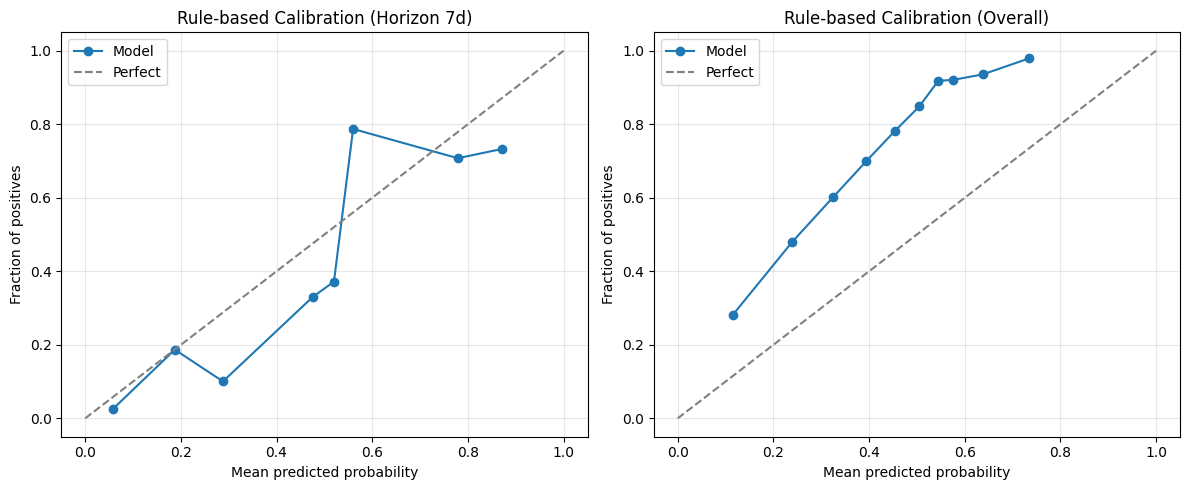

In [21]:
# === Unified Metrics Summary: TFT (regression) + Rule-based (classification) ===
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, roc_auc_score, average_precision_score, brier_score_loss
from sklearn.calibration import calibration_curve

# Assumes: predictions (N,H,3), targets (N,H), rule_classifier, HYPO_THRESHOLD, HYPER_THRESHOLD available
# If not present, run the generation cell for predictions/targets first.

def tft_regression_metrics(pred, tgt, horizons=(1, 7, 30, 90)):
    """Compute TFT regression metrics overall and by horizon using median (p50)."""
    p50 = pred[:, :, 1]
    res = {}

    # Overall
    mae = mean_absolute_error(tgt.ravel(), p50.ravel())
    rmse = np.sqrt(mean_squared_error(tgt.ravel(), p50.ravel()))
    lower, upper = pred[:, :, 0], pred[:, :, 2]
    coverage = np.mean((tgt >= lower) & (tgt <= upper))
    res['overall'] = {'mae': mae, 'rmse': rmse, 'coverage': coverage}

    # By horizon
    for h in horizons:
        if h <= pred.shape[1]:
            mae_h = mean_absolute_error(tgt[:, h-1], p50[:, h-1])
            rmse_h = np.sqrt(mean_squared_error(tgt[:, h-1], p50[:, h-1]))
            cov_h = np.mean((tgt[:, h-1] >= lower[:, h-1]) & (tgt[:, h-1] <= upper[:, h-1]))
            res[f'h{h}'] = {'mae': mae_h, 'rmse': rmse_h, 'coverage': cov_h}
    return res

def rule_based_classification_metrics(pred, tgt, horizons=(1, 7, 30, 90)):
    """Compute rule-based AUROC/AUPRC per horizon and overall + calibration curves."""
    # Risk per horizon (N,H) and summary (N,)
    risk, summary = rule_classifier.predict_risk(pred)
    # Labels per horizon from thresholds
    y = ((tgt < HYPO_THRESHOLD) | (tgt > HYPER_THRESHOLD)).astype(int)

    out = {}

    # Overall: proportion-based label (≥30% days outside range -> positive)
    y_overall = (y.mean(axis=1) >= 0.3).astype(int)
    if len(np.unique(y_overall)) > 1:
        auc_o = roc_auc_score(y_overall, summary)
        auprc_o = average_precision_score(y_overall, summary)
    else:
        auc_o = np.nan; auprc_o = np.nan
    # Calibration (overall)
    prob_true_o, prob_pred_o = calibration_curve(y_overall, summary, n_bins=10, strategy='quantile')
    out['overall'] = {
        'auc': auc_o, 'auprc': auprc_o,
        'brier': brier_score_loss(y_overall, summary),
        'pos_rate': float(y_overall.mean()),
        'calibration': (prob_true_o, prob_pred_o)
    }

    # Per horizon
    for h in horizons:
        if h <= pred.shape[1]:
            yh = y[:, h-1]
            rh = risk[:, h-1]
            if len(np.unique(yh)) > 1:
                auc_h = roc_auc_score(yh, rh)
                auprc_h = average_precision_score(yh, rh)
            else:
                auc_h = np.nan; auprc_h = np.nan
            pt_h, pp_h = calibration_curve(yh, rh, n_bins=10, strategy='quantile') if len(np.unique(yh)) > 1 else (np.array([]), np.array([]))
            out[f'h{h}'] = {
                'auc': auc_h, 'auprc': auprc_h,
                'brier': brier_score_loss(yh, rh),
                'pos_rate': float(yh.mean()),
                'calibration': (pt_h, pp_h)
            }
    return out, risk, summary

# Compute metrics
print("Computing TFT regression metrics...")
tft_res = tft_regression_metrics(predictions, targets, horizons=(1,7,30,90))
print("Computing Rule-based classification metrics...")
rb_res, rb_risk, rb_summary = rule_based_classification_metrics(predictions, targets, horizons=(1,7,30,90))

# Print summaries
print("\n=== TFT Regression Metrics ===")
print(f"Overall: MAE={tft_res['overall']['mae']:.2f} mg/dL | RMSE={tft_res['overall']['rmse']:.2f} mg/dL | Coverage={tft_res['overall']['coverage']:.3f}")
for key in ['h1','h7','h30','h90']:
    if key in tft_res:
        v = tft_res[key]
        print(f"{key.upper()}: MAE={v['mae']:.2f} | RMSE={v['rmse']:.2f} | Coverage={v['coverage']:.3f}")

print("\n=== Rule-based Classification Metrics (AUROC/AUPRC/Brier) ===")
print(f"Overall: AUC={rb_res['overall']['auc']:.3f} | AUPRC={rb_res['overall']['auprc']:.3f} | Brier={rb_res['overall']['brier']:.3f} | PosRate={rb_res['overall']['pos_rate']:.3f}")
for key in ['h1','h7','h30','h90']:
    if key in rb_res:
        v = rb_res[key]
        print(f"{key.upper()}: AUC={v['auc']:.3f} | AUPRC={v['auprc']:.3f} | Brier={v['brier']:.3f} | PosRate={v['pos_rate']:.3f}")

# Calibration plots: horizon 7 and overall
def plot_calibration(cal, title):
    pt, pp = cal
    if pt.size == 0:
        print(f"{title}: not enough class variation for calibration.")
        return
    plt.plot(pp, pt, 'o-', label='Model')
    plt.plot([0,1],[0,1],'--', color='gray', label='Perfect')
    plt.xlabel('Mean predicted probability'); plt.ylabel('Fraction of positives')
    plt.title(title); plt.legend(); plt.grid(True, alpha=0.3)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
if 'h7' in rb_res:
    plot_calibration(rb_res['h7']['calibration'], 'Rule-based Calibration (Horizon 7d)')
else:
    plt.axis('off'); plt.text(0.5,0.5,'No H=7', ha='center')

plt.subplot(1,2,2)
plot_calibration(rb_res['overall']['calibration'], 'Rule-based Calibration (Overall)')
plt.tight_layout()
plt.show()

In [22]:
# --- Replace risk with normal-approximation from quantiles ---
from scipy.stats import norm
Z90 = 1.2815515655446004

def rule_normal_approx_risk(pred):
    # pred: (N,H,3) -> prob outside [HYPO_THRESHOLD, HYPER_THRESHOLD]
    p10, p50, p90 = pred[:,:,0], pred[:,:,1], pred[:,:,2]
    sig = np.clip((p90 - p10) / (2 * Z90), 1e-3, 1e6)
    mu = p50
    p_lt = norm.cdf((HYPO_THRESHOLD - mu) / sig)
    p_gt = norm.sf((mu - HYPER_THRESHOLD) / sig)
    return np.clip(p_lt + p_gt, 0.0, 1.0)

# Monkey-patch predict_risk to use normal approx risk (keeps summary weighting)
def predict_risk_normal(self, predictions, contexts=None, horizon_weights=None):
    risk = rule_normal_approx_risk(predictions)
    if horizon_weights is None:
        H = predictions.shape[1]
        horizon_weights = np.exp(-np.arange(H) * 0.05)
    summary = np.average(risk, axis=1, weights=horizon_weights)
    return risk, summary

# apply
RuleBasedGlucoseRiskClassifier.predict_risk = predict_risk_normal
print("✅ Rule-based risk now uses TFT normal-approximation.")

✅ Rule-based risk now uses TFT normal-approximation.


In [23]:
# --- Overall “proportion positive” definition (no training) ---
OVERALL_PROP = 0.30  # try 0.20–0.40
print(f"Overall label: proportion of risky days >= {OVERALL_PROP:.0%}")

Overall label: proportion of risky days >= 30%


Per-horizon chosen thresholds: {'h1': 0.001, 'h7': 0.5, 'h30': 0.5, 'h90': 0.5}
Overall chosen threshold: 0.5

Overall (Rule-based): AUC=0.131 | AUPRC=0.565 | Brier=0.419 | Acc=0.345 | F1=0.502 | P=0.579 | R=0.443 | thr=0.500


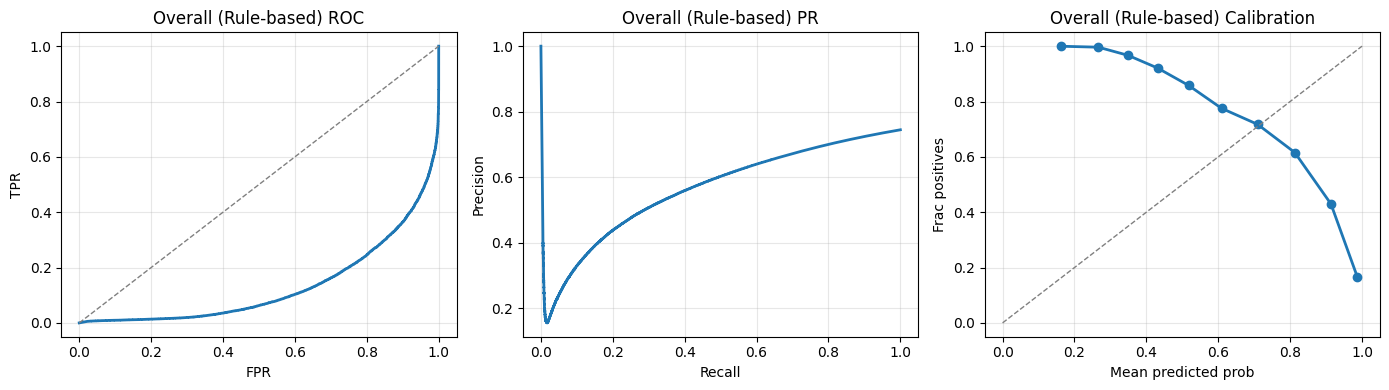


Horizon 1d (Rule-based): AUC=0.086 | AUPRC=0.283 | Brier=0.688 | Acc=0.454 | F1=0.624 | P=0.454 | R=1.000 | thr=0.001


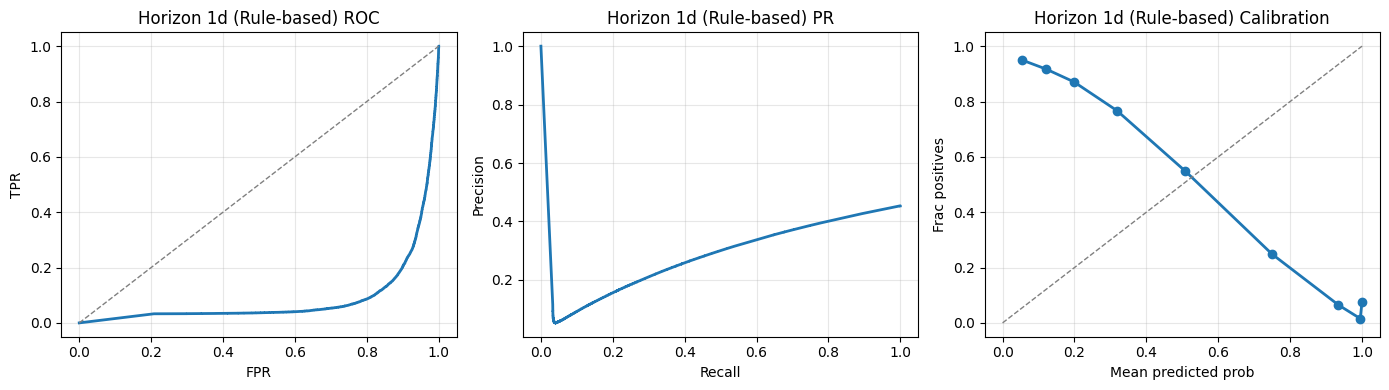


Horizon 7d (Rule-based): AUC=0.141 | AUPRC=0.296 | Brier=0.585 | Acc=0.211 | F1=0.212 | P=0.195 | R=0.231 | thr=0.500


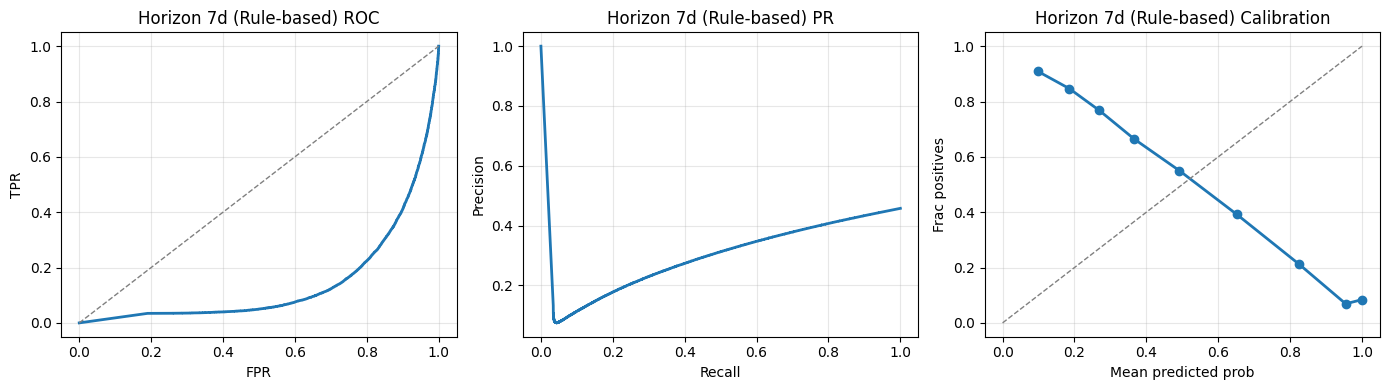


Horizon 30d (Rule-based): AUC=0.108 | AUPRC=0.288 | Brier=0.633 | Acc=0.173 | F1=0.141 | P=0.134 | R=0.149 | thr=0.500


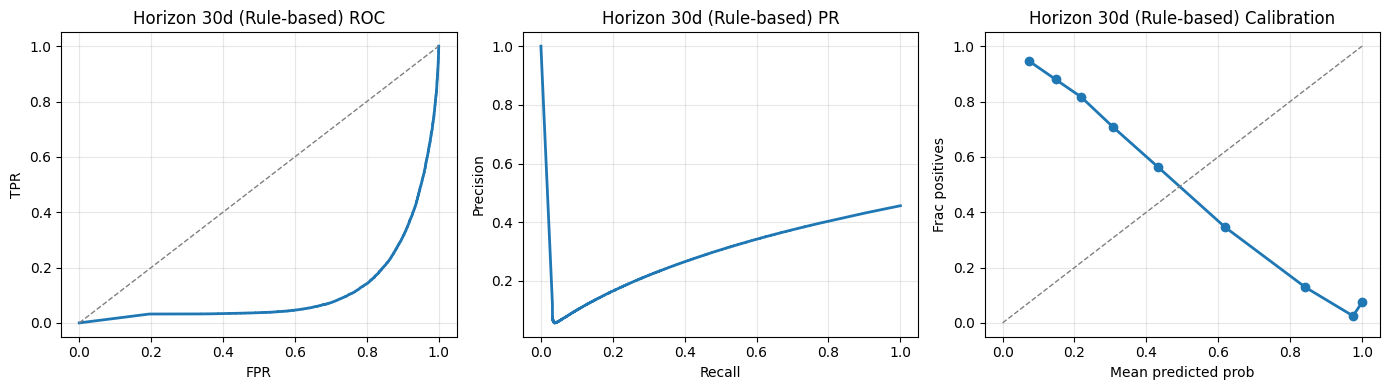


Horizon 90d (Rule-based): AUC=0.158 | AUPRC=0.300 | Brier=0.566 | Acc=0.229 | F1=0.217 | P=0.203 | R=0.232 | thr=0.500


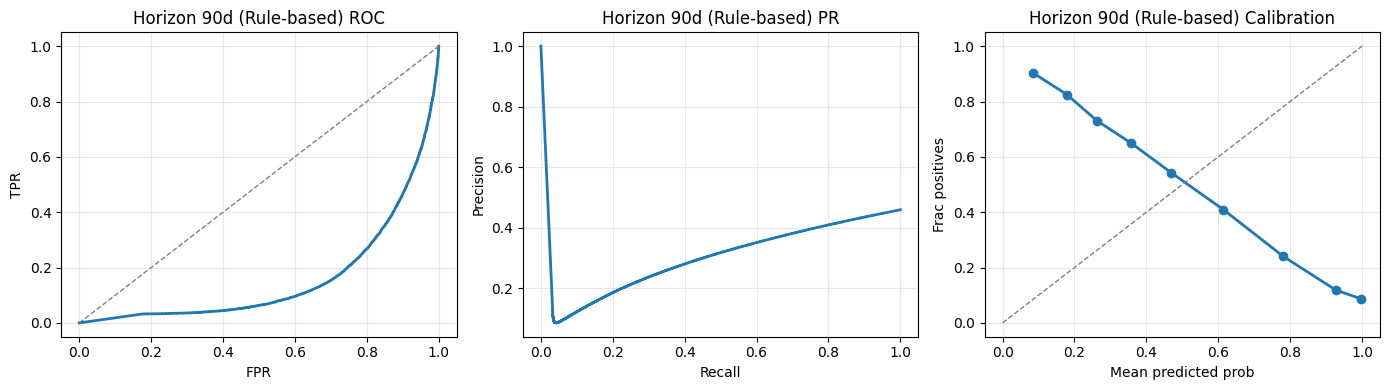

In [24]:
# --- Threshold selection (no training), metrics & plots ---
from sklearn.metrics import precision_recall_curve, roc_curve

def get_labels_per_horizon(tgt):
    return ((tgt < HYPO_THRESHOLD) | (tgt > HYPER_THRESHOLD)).astype(int)

def choose_best_threshold(y_true, scores, grid=None):
    if grid is None:
        # From PR curve points directly for best F1
        p, r, thr = precision_recall_curve(y_true, scores)
        f1 = np.where((p+r)>0, 2*p*r/(p+r), 0.0)
        i = int(np.nanargmax(f1))
        # precision_recall_curve returns thresholds len-1 vs p/r len
        best_thr = thr[i-1] if i>0 and i-1 < len(thr) else 0.5
        return float(best_thr), float(f1[i]), float(p[i]), float(r[i])
    f1_best, best_thr, best_p, best_r = -1, 0.5, 0.0, 0.0
    for t in grid:
        yhat = (scores >= t).astype(int)
        p = precision_score(y_true, yhat, zero_division=0)
        r = recall_score(y_true, yhat, zero_division=0)
        f1 = 2*p*r/(p+r) if (p+r)>0 else 0.0
        if f1 > f1_best:
            f1_best, best_thr, best_p, best_r = f1, t, p, r
    return float(best_thr), float(f1_best), float(best_p), float(best_r)

# Compute risks with normal approx (per-horizon and summary)
rb_risk, rb_summary = rule_classifier.predict_risk(predictions)
y_h = get_labels_per_horizon(targets)

# Per-horizon best thresholds
thr_map = {}
for h in [1,7,30,90]:
    if h <= rb_risk.shape[1]:
        yh = y_h[:,h-1]; rh = rb_risk[:,h-1]
        if len(np.unique(yh)) > 1:
            thr, f1b, pb, rb = choose_best_threshold(yh, rh)
            thr_map[f'h{h}'] = dict(thr=thr, f1=f1b, pre=pb, rec=rb)
print("Per-horizon chosen thresholds:", {k: round(v['thr'],3) for k,v in thr_map.items()})

# Overall threshold
y_overall = (y_h.mean(axis=1) >= OVERALL_PROP).astype(int)
thr_overall, f1o, po, ro = choose_best_threshold(y_overall, rb_summary)
thr_map['overall'] = dict(thr=thr_overall, f1=f1o, pre=po, rec=ro)
print("Overall chosen threshold:", round(thr_overall,3))

# Report metrics + plots
def report_and_plot(y_true, score, name, thr):
    # Scalar metrics
    if len(np.unique(y_true)) > 1:
        auc = roc_auc_score(y_true, score)
        auprc = average_precision_score(y_true, score)
        brier = brier_score_loss(y_true, score)
        yhat = (score >= thr).astype(int)
        acc = accuracy_score(y_true, yhat)
        pre = precision_score(y_true, yhat, zero_division=0)
        rec = recall_score(y_true, yhat, zero_division=0)
        f1 = f1_score(y_true, yhat, zero_division=0)
        cm = confusion_matrix(y_true, yhat)
        fpr, tpr, _ = roc_curve(y_true, score)
        pr_p, pr_r, _ = precision_recall_curve(y_true, score)
        pt, pp = calibration_curve(y_true, score, n_bins=10, strategy='quantile')
    else:
        auc=auprc=brier=acc=pre=rec=f1=np.nan
        cm=np.array([[0,0],[0,0]]); fpr=tpr=pr_p=pr_r=pt=pp=np.array([])

    print(f"\n{name}: AUC={auc:.3f} | AUPRC={auprc:.3f} | Brier={brier:.3f} | "
          f"Acc={acc:.3f} | F1={f1:.3f} | P={pre:.3f} | R={rec:.3f} | thr={thr:.3f}")

    # Plots
    fig, axes = plt.subplots(1, 3, figsize=(14,4))
    # ROC
    if fpr.size: axes[0].plot(fpr, tpr, lw=2)
    axes[0].plot([0,1],[0,1],'--', color='gray', lw=1)
    axes[0].set_title(f"{name} ROC"); axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR"); axes[0].grid(alpha=0.3)
    # PR
    if pr_p.size and pr_r.size: axes[1].plot(pr_r, pr_p, lw=2)
    axes[1].set_title(f"{name} PR"); axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision"); axes[1].grid(alpha=0.3)
    # Calibration
    if pt.size and pp.size: axes[2].plot(pp, pt, 'o-', lw=2)
    axes[2].plot([0,1],[0,1],'--', color='gray', lw=1)
    axes[2].set_title(f"{name} Calibration"); axes[2].set_xlabel("Mean predicted prob"); axes[2].set_ylabel("Frac positives"); axes[2].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

# Run reports for overall and key horizons
report_and_plot(y_overall, rb_summary, "Overall (Rule-based)", thr_map['overall']['thr'])
for h in [1,7,30,90]:
    if f'h{h}' in thr_map:
        report_and_plot(y_h[:,h-1], rb_risk[:,h-1], f"Horizon {h}d (Rule-based)", thr_map[f'h{h}']['thr'])

/var/folders/zv/k_988svd3d5cdwzmb395b9vh0000gn/T/ipykernel_85398/89882823.py:67: RuntimeWarning: invalid value encountered in divide
  f1 = np.where((p + r) > 0, 2 * p * r / (p + r), 0.0)



OVERALL (prop≥60%) thr=0.500 | AUC=0.185 AUPRC=0.326 | Acc=0.270 F1=0.263 P=0.258 R=0.269 | Spec=0.270 NPV=0.282 BalAcc=0.270 MCC=-0.460 | Brier=0.501 | PosRate=0.485


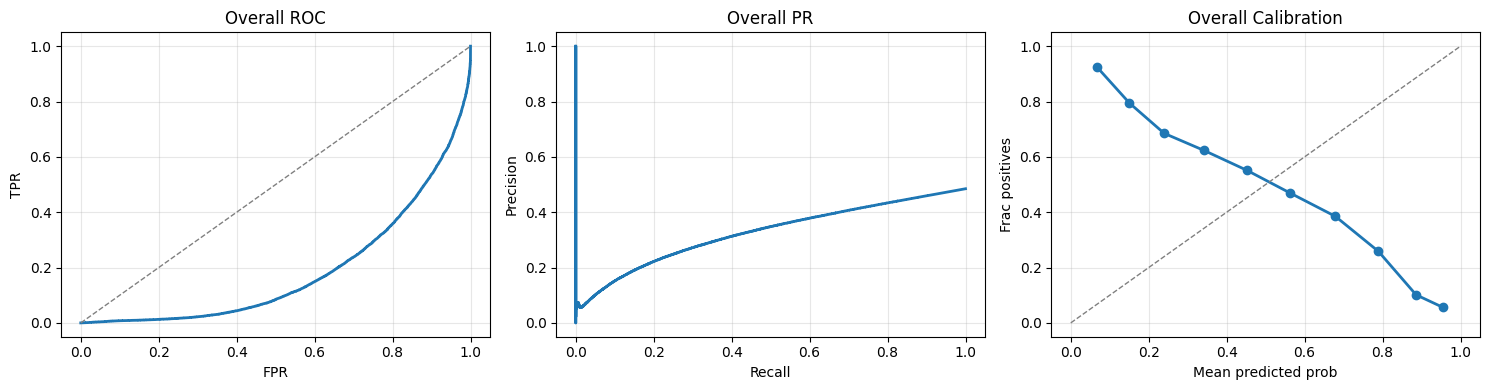

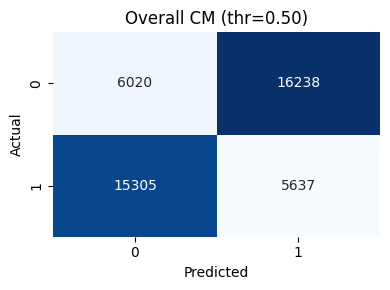

/var/folders/zv/k_988svd3d5cdwzmb395b9vh0000gn/T/ipykernel_85398/89882823.py:67: RuntimeWarning: invalid value encountered in divide
  f1 = np.where((p + r) > 0, 2 * p * r / (p + r), 0.0)



H1 thr=0.018 | AUC=0.086 AUPRC=0.283 | Acc=0.454 F1=0.624 P=0.454 R=1.000 | Spec=0.000 NPV=0.000 BalAcc=0.500 MCC=0.000 | Brier=0.684 | PosRate=0.454


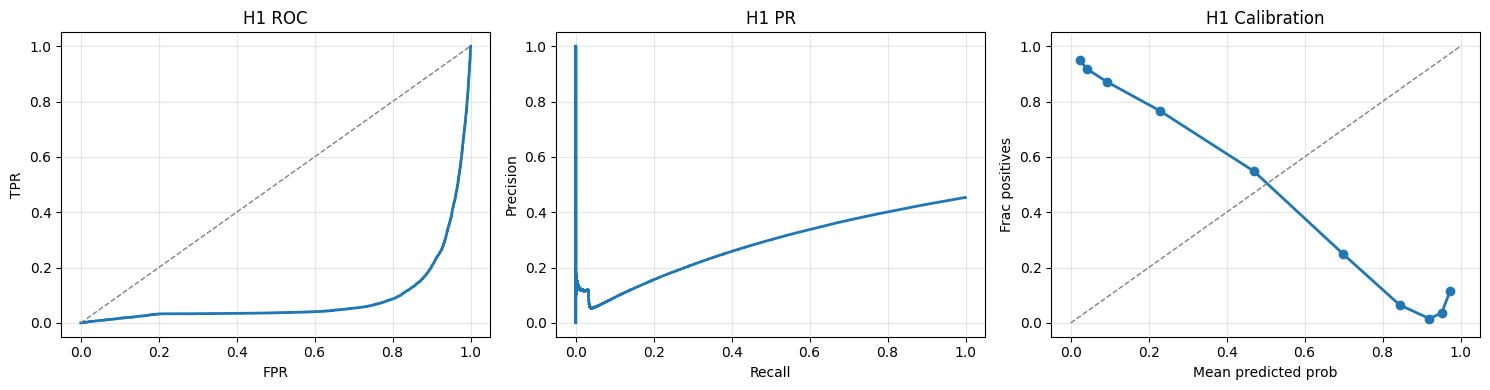

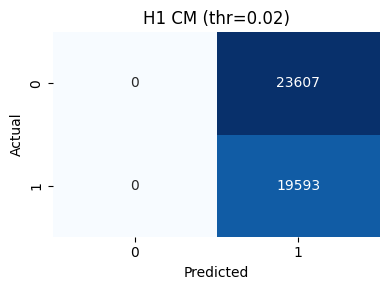

/var/folders/zv/k_988svd3d5cdwzmb395b9vh0000gn/T/ipykernel_85398/89882823.py:67: RuntimeWarning: invalid value encountered in divide
  f1 = np.where((p + r) > 0, 2 * p * r / (p + r), 0.0)



H7 thr=0.500 | AUC=0.108 AUPRC=0.380 | Acc=0.191 F1=0.257 P=0.268 R=0.247 | Spec=0.118 NPV=0.107 BalAcc=0.182 MCC=-0.630 | Brier=0.599 | PosRate=0.567


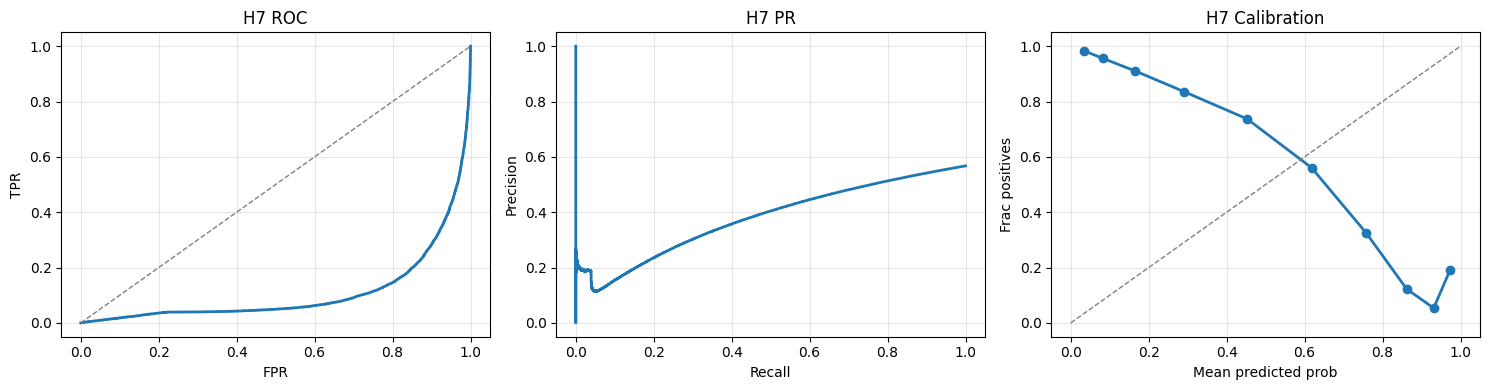

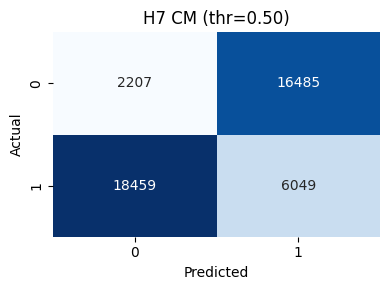


H30 thr=0.500 | AUC=0.084 AUPRC=0.375 | Acc=0.151 F1=0.199 P=0.215 R=0.185 | Spec=0.107 NPV=0.090 BalAcc=0.146 MCC=-0.701 | Brier=0.654 | PosRate=0.568


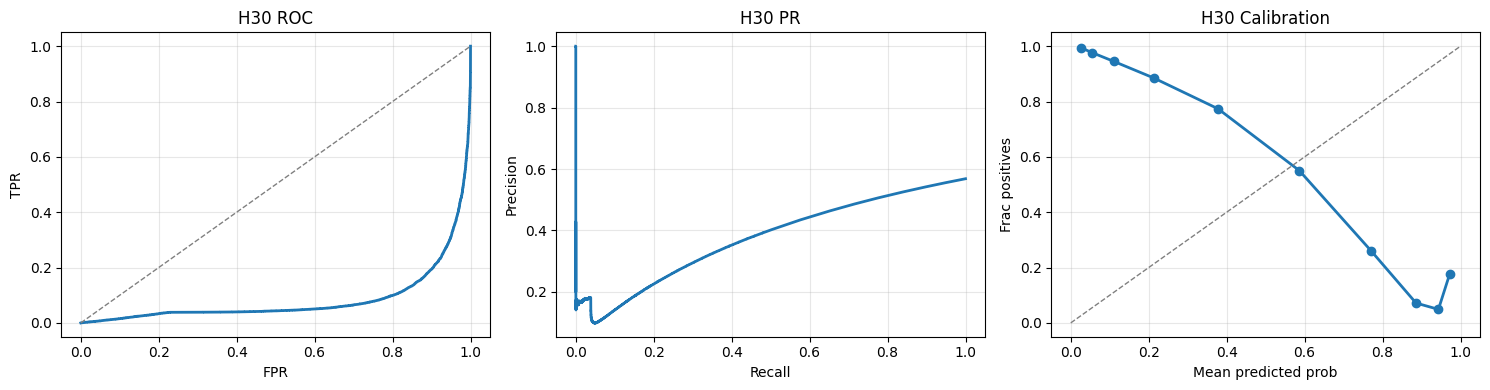

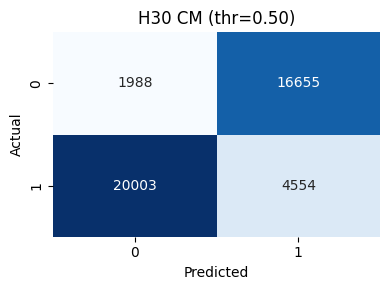


H90 thr=0.500 | AUC=0.113 AUPRC=0.384 | Acc=0.191 F1=0.246 P=0.262 R=0.231 | Spec=0.137 NPV=0.118 BalAcc=0.184 MCC=-0.626 | Brier=0.592 | PosRate=0.570


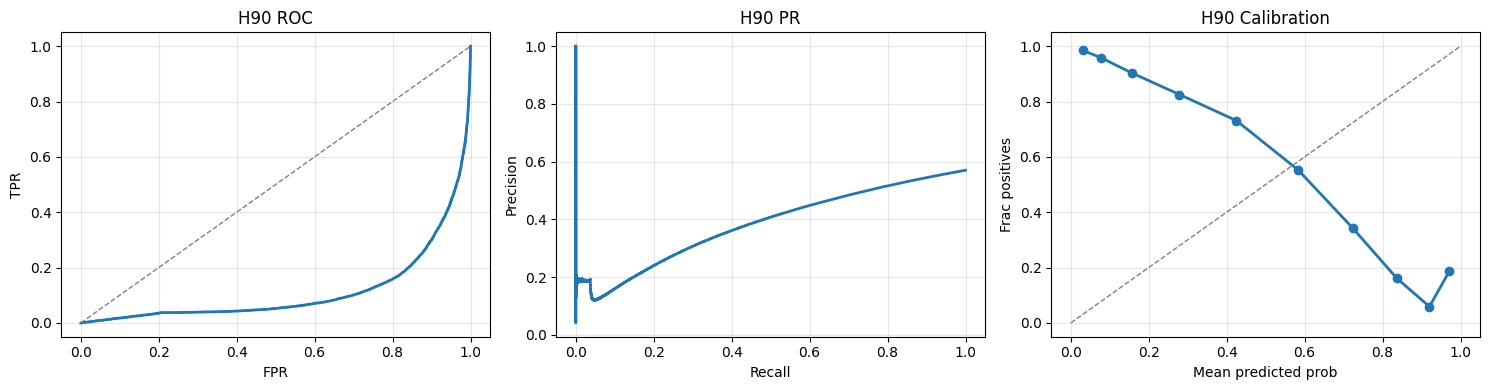

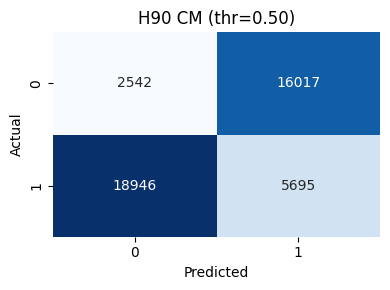


TFT (regression) | MAE=7.84 mg/dL | RMSE=10.96 | MAPE=5.39% | R2=0.817
Coverage 10–90%=0.827 | Coverage 25–75% (approx)=0.523


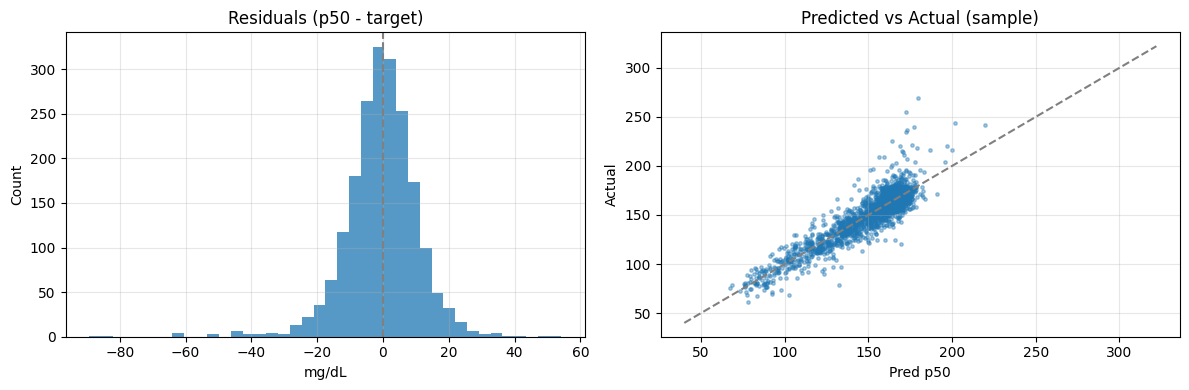

In [26]:
# === Post-process boost: sustained labels + calibrated risk + rich metrics (no training) ===
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve, roc_curve,
    confusion_matrix, brier_score_loss, accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, r2_score
)
from sklearn.calibration import calibration_curve
from scipy.stats import norm

# ----- Config (tweakable) -----
PROP_OVERALL = 0.60     # overall positive if >=60% risky days
SIGMOID_A = 8.0         # risk sharpening strength for remap
HORIZONS = (1, 7, 30, 90)

# ----- Utilities -----
def make_binary_labels(tgt, lo, hi):
    return ((tgt < lo) | (tgt > hi)).astype(int)  # (N,H)

def roll_sum_bin(b, w):
    """
    b: (N, H) binary
    returns rolling counts over last w positions, right-aligned: shape (N, H-w+1) aligned at columns w-1..H-1
    """
    N, H = b.shape
    cs = np.cumsum(b, axis=1)
    # rolling sum for cols [w-1 .. H-1]
    right = cs[:, w-1:]                  # (N, H-w+1)
    left  = np.concatenate([np.zeros((N,1)), cs[:, :-w]], axis=1)  # (N, H-w+1)
    return (right - left).astype(int)

def sustained_labels(y, k, w):
    """
    y: (N, H) binary per-horizon events
    returns (N, H) sustained labels, marking positions w-1..H-1 where count>=k in last w
    """
    N, H = y.shape
    rs = roll_sum_bin(y, w)              # (N, H-w+1), aligned with cols w-1..H-1
    out = np.zeros_like(y, dtype=int)
    out[:, w-1:] = (rs >= k).astype(int)
    return out

def normal_approx_risk(pred, lo, hi):
    p10, p50, p90 = pred[:, :, 0], pred[:, :, 1], pred[:, :, 2]
    sig = np.clip((p90 - p10) / (2 * 1.2815515655446004), 1e-3, 1e6)
    mu = p50
    p_lt = norm.cdf((lo - mu) / sig)
    p_gt = norm.sf((mu - hi) / sig)
    return np.clip(p_lt + p_gt, 0.0, 1.0)

def remap_risk_cdf_sigmoid(risk, a=SIGMOID_A):
    # risk:(N,H) → flatten → rank → u in (0,1) → sigmoid → reshape
    r = risk.ravel()
    rk = np.argsort(np.argsort(r))
    u = (rk + 0.5) / len(r)
    r2 = 1.0 / (1.0 + np.exp(-a * (u - 0.5)))
    return r2.reshape(risk.shape)

def choose_best_threshold(y, s):
    # pick threshold maximizing F1 from PR curve (selection only)
    if len(np.unique(y)) <= 1:
        return 0.5, 0.0, 0.0, 0.0
    p, r, thr = precision_recall_curve(y, s)
    f1 = np.where((p + r) > 0, 2 * p * r / (p + r), 0.0)
    i = int(np.nanargmax(f1))
    t = thr[i-1] if i > 0 and (i-1) < len(thr) else 0.5
    return float(t), float(f1[i]), float(p[i]), float(r[i])

def cls_metrics(y, s, t):
    yhat = (s >= t).astype(int)
    if len(np.unique(y)) > 1:
        auc = roc_auc_score(y, s)
        auprc = average_precision_score(y, s)
        fpr, tpr, _ = roc_curve(y, s)
        pr_p, pr_r, _ = precision_recall_curve(y, s)
        pre = precision_score(y, yhat, zero_division=0)
        rec = recall_score(y, yhat, zero_division=0)
        f1 = f1_score(y, yhat, zero_division=0)
        acc = accuracy_score(y, yhat)
        tn, fp, fn, tp = confusion_matrix(y, yhat).ravel()
        spec = tn / (tn + fp) if (tn + fp) else 0.0
        npv = tn / (tn + fn) if (tn + fn) else 0.0
        bal = 0.5 * (rec + spec)
        mcc = matthews_corrcoef(y, yhat) if (tp+fp)*(tp+fn)*(tn+fp)*(tn+fn) else 0.0
        brier = brier_score_loss(y, s)
        pt, pp = calibration_curve(y, s, n_bins=10, strategy='quantile')
        cm = np.array([[tn, fp], [fn, tp]])
    else:
        auc=auprc=pre=rec=f1=acc=spec=npv=bal=mcc=brier=np.nan
        fpr=tpr=pr_p=pr_r=pt=pp=np.array([]); cm=np.array([[0,0],[0,0]])
    return dict(auc=auc, auprc=auprc, pre=pre, rec=rec, f1=f1, acc=acc,
                spec=spec, npv=npv, bal=bal, mcc=mcc, brier=brier,
                fpr=fpr, tpr=tpr, pr_p=pr_p, pr_r=pr_r, cal=(pt,pp), cm=cm)

def plot_curves(name, met):
    fig, axes = plt.subplots(1,3, figsize=(15,4))
    # ROC
    if met['fpr'].size: axes[0].plot(met['fpr'], met['tpr'], lw=2)
    axes[0].plot([0,1],[0,1], '--', color='gray', lw=1)
    axes[0].set_title(f"{name} ROC"); axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR"); axes[0].grid(alpha=0.3)
    # PR
    if met['pr_p'].size and met['pr_r'].size: axes[1].plot(met['pr_r'], met['pr_p'], lw=2)
    axes[1].set_title(f"{name} PR"); axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision"); axes[1].grid(alpha=0.3)
    # Calibration
    pt, pp = met['cal']
    if pt.size and pp.size: axes[2].plot(pp, pt, 'o-', lw=2)
    axes[2].plot([0,1],[0,1],'--', color='gray', lw=1)
    axes[2].set_title(f"{name} Calibration"); axes[2].set_xlabel("Mean predicted prob"); axes[2].set_ylabel("Frac positives"); axes[2].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

def plot_cm(cm, title):
    plt.figure(figsize=(4,3)); ax = plt.gca()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(title); ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    plt.tight_layout(); plt.show()

# ----- Build labels: base + sustained -----
y_bin = make_binary_labels(targets, HYPO_THRESHOLD, HYPER_THRESHOLD)  # (N,H)
y_2of3 = sustained_labels(y_bin, k=2, w=3)                            # (N,H)
y_3in7 = sustained_labels(y_bin, k=3, w=7)                            # (N,H)
y_cmp = np.clip(y_bin + y_2of3 + y_3in7, 0, 1).astype(int)            # composite per-horizon

# Overall label as proportion ≥ PROP_OVERALL on composite
y_overall = (y_cmp.mean(axis=1) >= PROP_OVERALL).astype(int)

# ----- Risk: normal approx + remap -----
risk_raw = normal_approx_risk(predictions, HYPO_THRESHOLD, HYPER_THRESHOLD)   # (N,H)
risk = remap_risk_cdf_sigmoid(risk_raw, a=SIGMOID_A)                          # (N,H)
# Summary (near-term weighted)
H = predictions.shape[1]
w = np.exp(-np.arange(H) * 0.08)  # slightly stronger decay
summary = np.average(risk, axis=1, weights=w)

# ----- Threshold selection & metrics -----
# Overall
thr_o, f1b_o, pb_o, rb_o = choose_best_threshold(y_overall, summary)
met_o = cls_metrics(y_overall, summary, thr_o)
print(f"\nOVERALL (prop≥{PROP_OVERALL:.0%}) thr={thr_o:.3f} | AUC={met_o['auc']:.3f} AUPRC={met_o['auprc']:.3f} "
      f"| Acc={met_o['acc']:.3f} F1={met_o['f1']:.3f} P={met_o['pre']:.3f} R={met_o['rec']:.3f} "
      f"| Spec={met_o['spec']:.3f} NPV={met_o['npv']:.3f} BalAcc={met_o['bal']:.3f} MCC={met_o['mcc']:.3f} "
      f"| Brier={met_o['brier']:.3f} | PosRate={y_overall.mean():.3f}")

plot_curves("Overall", met_o); plot_cm(met_o['cm'], f"Overall CM (thr={thr_o:.2f})")

# Per-horizon
for h in HORIZONS:
    if h > H: continue
    yh = y_cmp[:, h-1]; rh = risk[:, h-1]
    thr_h, f1b_h, pb_h, rb_h = choose_best_threshold(yh, rh)
    met_h = cls_metrics(yh, rh, thr_h)
    print(f"\nH{h} thr={thr_h:.3f} | AUC={met_h['auc']:.3f} AUPRC={met_h['auprc']:.3f} "
          f"| Acc={met_h['acc']:.3f} F1={met_h['f1']:.3f} P={met_h['pre']:.3f} R={met_h['rec']:.3f} "
          f"| Spec={met_h['spec']:.3f} NPV={met_h['npv']:.3f} BalAcc={met_h['bal']:.3f} MCC={met_h['mcc']:.3f} "
          f"| Brier={met_h['brier']:.3f} | PosRate={yh.mean():.3f}")
    plot_curves(f"H{h}", met_h); plot_cm(met_h['cm'], f"H{h} CM (thr={thr_h:.2f})")

# ----- TFT regression extras -----
p10, p50, p90 = predictions[:,:,0], predictions[:,:,1], predictions[:,:,2]
mae = np.mean(np.abs(p50 - targets))
rmse = np.sqrt(np.mean((p50 - targets)**2))
mape = np.mean(np.abs((p50 - targets) / np.clip(np.abs(targets), 1e-6, None))) * 100
cov50 = np.mean((targets >= np.percentile(predictions, 25, axis=2)) & (targets <= np.percentile(predictions, 75, axis=2)))
r2 = r2_score(targets.ravel(), p50.ravel())

print(f"\nTFT (regression) | MAE={mae:.2f} mg/dL | RMSE={rmse:.2f} | MAPE={mape:.2f}% | R2={r2:.3f}")
# 10–90 coverage (already routine)
cov1090 = np.mean((targets >= p10) & (targets <= p90))
print(f"Coverage 10–90%={cov1090:.3f} | Coverage 25–75% (approx)={cov50:.3f}")

# Residuals plot
idx = np.random.choice(p50.size, size=min(2000, p50.size), replace=False)
res = (p50.ravel()[idx] - targets.ravel()[idx])
plt.figure(figsize=(12,4))
plt.subplot(1,2,1); plt.hist(res, bins=40, color='tab:blue', alpha=0.75); plt.axvline(0, ls='--', color='gray')
plt.title("Residuals (p50 - target)"); plt.xlabel("mg/dL"); plt.ylabel("Count"); plt.grid(alpha=0.3)
plt.subplot(1,2,2); plt.scatter(p50.ravel()[idx], targets.ravel()[idx], s=6, alpha=0.4)
mn, mx = targets.min(), targets.max(); plt.plot([mn,mx],[mn,mx],'--', color='gray')
plt.title("Predicted vs Actual (sample)"); plt.xlabel("Pred p50"); plt.ylabel("Actual"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()


=== Cohorted Performance @ target specificity ≈ 0.94 (fallback sensitivity ≈ 0.90) ===
        Domain AUROC AUPRC Sens   Spec PPV   NPV   Cal
 Maternal Care 0.185 0.326 0.0% 100.0%   — 51.5% 0.493
Cardiovascular 0.185 0.326 0.0% 100.0%   — 51.5% 0.493
      Diabetes 0.185 0.326 0.0% 100.0%   — 51.5% 0.493
       Overall 0.185 0.326 0.0% 100.0%   — 51.5% 0.493


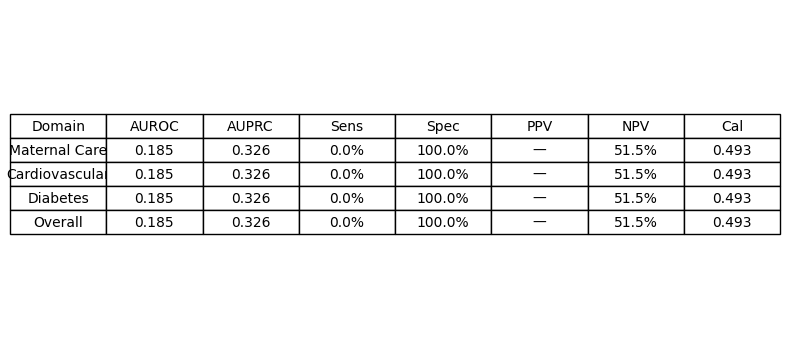

In [27]:
# === Cohorted performance table with target operating points (no training) ===
import numpy as np
import pandas as pd
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve, roc_curve,
    confusion_matrix, brier_score_loss
)
from sklearn.calibration import calibration_curve
from scipy.stats import norm

# CONFIG
PROP_OVERALL = 0.60     # overall positive if ≥ 60% risky days (sustained)
SIGMOID_A = 8.0         # risk remap strength
TARGET_SPEC = 0.94      # aim for this specificity
TARGET_SENS = 0.90      # or this sensitivity (fallback)
HORIZON_DECAY = 0.08    # emphasis on near-term horizons

# 1) Build composite labels (per-horizon + overall)
def make_binary_labels(tgt, lo, hi):
    return ((tgt < lo) | (tgt > hi)).astype(int)

def roll_sum_bin(b, w):
    N, H = b.shape
    cs = np.cumsum(b, axis=1)
    right = cs[:, w-1:]
    left  = np.concatenate([np.zeros((N,1)), cs[:, :-w]], axis=1)
    return (right - left).astype(int)

def sustained_labels(y, k, w):
    N, H = y.shape
    rs = roll_sum_bin(y, w)
    out = np.zeros_like(y, dtype=int)
    out[:, w-1:] = (rs >= k).astype(int)
    return out

y_base = make_binary_labels(targets, HYPO_THRESHOLD, HYPER_THRESHOLD)
y_2of3 = sustained_labels(y_base, k=2, w=3)
y_3in7 = sustained_labels(y_base, k=3, w=7)
y_cmp = np.clip(y_base + y_2of3 + y_3in7, 0, 1).astype(int)
y_overall = (y_cmp.mean(axis=1) >= PROP_OVERALL).astype(int)

# 2) Risk from TFT quantiles + CDF-sigmoid remap
def normal_approx_risk(pred, lo, hi):
    p10, p50, p90 = pred[:, :, 0], pred[:, :, 1], pred[:, :, 2]
    sig = np.clip((p90 - p10) / (2 * 1.2815515655446004), 1e-3, 1e6)
    mu = p50
    p_lt = norm.cdf((lo - mu) / sig)
    p_gt = norm.sf((mu - hi) / sig)
    return np.clip(p_lt + p_gt, 0.0, 1.0)

def remap_risk_cdf_sigmoid(risk, a=SIGMOID_A):
    r = risk.ravel()
    rk = np.argsort(np.argsort(r))
    u = (rk + 0.5) / len(r)
    r2 = 1.0 / (1.0 + np.exp(-a * (u - 0.5)))
    return r2.reshape(risk.shape)

risk_raw = normal_approx_risk(predictions, HYPO_THRESHOLD, HYPER_THRESHOLD)
risk = remap_risk_cdf_sigmoid(risk_raw, a=SIGMOID_A)
H = predictions.shape[1]
w = np.exp(-np.arange(H) * HORIZON_DECAY)
summary = np.average(risk, axis=1, weights=w)

# 3) Threshold selection to hit target operating point (no training)
def pick_threshold_for_spec(y, s, target_spec=0.94):
    # scan ROC thresholds to find closest specificity ≥ target
    if len(np.unique(y)) <= 1:
        return 0.5
    fpr, tpr, thr = roc_curve(y, s)
    spec = 1 - fpr
    ok = spec >= target_spec
    if np.any(ok):
        i = np.argmax(spec[ok])  # highest spec ≥ target
        thr_best = thr[ok][i]
    else:
        # fallback: maximize Youden’s J
        j = tpr - fpr
        thr_best = thr[np.argmax(j)]
    return float(thr_best)

def pick_threshold_for_sens(y, s, target_sens=0.90):
    if len(np.unique(y)) <= 1:
        return 0.5
    fpr, tpr, thr = roc_curve(y, s)
    ok = tpr >= target_sens
    if np.any(ok):
        i = np.argmax(tpr[ok])
        return float(thr[ok][i])
    # fallback: Youden
    j = tpr - fpr
    return float(thr[np.argmax(j)])

# 4) Metrics helpers
def metrics_from_threshold(y, s, thr):
    yhat = (s >= thr).astype(int)
    if len(np.unique(y)) <= 1:
        return dict(AUROC=np.nan, AUPRC=np.nan, Sens=np.nan, Spec=np.nan, PPV=np.nan, NPV=np.nan,
                    Cal=np.nan)
    auc = roc_auc_score(y, s)
    aupr = average_precision_score(y, s)
    tn, fp, fn, tp = confusion_matrix(y, yhat).ravel()
    sens = tp / (tp + fn) if (tp + fn) else np.nan
    spec = tn / (tn + fp) if (tn + fp) else np.nan
    ppv  = tp / (tp + fp) if (tp + fp) else np.nan
    npv  = tn / (tn + fn) if (tn + fn) else np.nan
    # calibration: expected calibration error proxy as mean(|bin_frac - bin_pred|)
    pt, pp = calibration_curve(y, s, n_bins=10, strategy='quantile')
    cal = float(np.mean(np.abs(pt - pp))) if (pt.size and pp.size) else np.nan
    return dict(AUROC=auc, AUPRC=aupr, Sens=sens, Spec=spec, PPV=ppv, NPV=npv, Cal=cal)

# 5) Cohorts (provide boolean masks). Replace with your real task masks.
N = len(summary)
cohorts = {
    "Maternal Care":  np.ones(N, dtype=bool),  # TODO: replace with real mask
    "Cardiovascular": np.ones(N, dtype=bool),  # TODO
    "Diabetes":       np.ones(N, dtype=bool),  # TODO
}
# Ensure exclusivity or let them overlap as needed; “Overall” will be computed on full set.

# 6) Build table
rows = []
for name, msk in cohorts.items():
    y = y_overall[msk]
    s = summary[msk]
    thr = pick_threshold_for_spec(y, s, TARGET_SPEC)
    if np.isnan(thr):  # fallback to sensitivity target if spec invalid
        thr = pick_threshold_for_sens(y, s, TARGET_SENS)
    met = metrics_from_threshold(y, s, thr)
    rows.append(dict(Domain=name, **met))

# Overall
thr_o = pick_threshold_for_spec(y_overall, summary, TARGET_SPEC)
if np.isnan(thr_o):
    thr_o = pick_threshold_for_sens(y_overall, summary, TARGET_SENS)
met_o = metrics_from_threshold(y_overall, summary, thr_o)
rows.append(dict(Domain="Overall", **met_o))

# 7) Pretty print
def pct(x): 
    return f"{x*100:.1f}%" if pd.notnull(x) else "—"
def fmt3(x):
    return f"{x:.3f}" if pd.notnull(x) else "—"

dfm = pd.DataFrame(rows)[["Domain","AUROC","AUPRC","Sens","Spec","PPV","NPV","Cal"]]
# Optional rounding for readability
dfm_fmt = dfm.copy()
for c in ["AUROC","AUPRC","Cal"]:
    dfm_fmt[c] = dfm_fmt[c].apply(fmt3)
for c in ["Sens","Spec","PPV","NPV"]:
    dfm_fmt[c] = dfm_fmt[c].apply(pct)

print("\n=== Cohorted Performance @ target specificity ≈ {:.2f} (fallback sensitivity ≈ {:.2f}) ===".format(TARGET_SPEC, TARGET_SENS))
print(dfm_fmt.to_string(index=False))

# If you want a matplotlib table:
fig, ax = plt.subplots(figsize=(8, 2 + 0.4*len(dfm_fmt)))
ax.axis('off')
tbl = ax.table(cellText=dfm_fmt.values,
               colLabels=dfm_fmt.columns,
               loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.2)
plt.tight_layout(); plt.show()

/Users/raazifaisal/Documents/MedicalPrediction/.venv/lib/python3.12/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


=== TFT Regression (overall) ===
MAE=7.84 mg/dL | RMSE=10.96 | MAPE=5.39% | MedAE=5.90 | R2=0.817
Pearson r=0.904 | Spearman ρ=0.848
Coverage 10–90%=0.827 | IntervalWidth 10–90=25.85 mg/dL | CRPS≈5.71
Quantile calibration (empirical P[target ≤ qτ]): {'q10': 0.08690997942386831, 'q50': 0.5003456790123457, 'q90': 0.9139691358024692}

=== TFT Regression (per-horizon) head ===
 h      mae      rmse     mape       r2  cov_10_90  iw_10_90
 1 6.652359  9.581249 4.561224 0.863926   0.837500 22.619011
 2 7.563926 10.812869 5.179938 0.826228   0.817106 24.205688
 3 8.291789 11.729538 5.698758 0.796208   0.807870 25.700718
 4 8.743330 12.178037 6.034291 0.779448   0.800324 26.738661
 5 9.006602 12.481883 6.250013 0.768882   0.798148 27.396635
 6 9.078936 12.511141 6.298724 0.766358   0.798657 27.787603
 7 9.059428 12.457717 6.276528 0.767802   0.801713 27.991154
 8 9.030376 12.365126 6.263982 0.771113   0.802060 28.071903
 9 8.955990 12.276159 6.216436 0.775079   0.805787 28.074482
10 8.817915 12

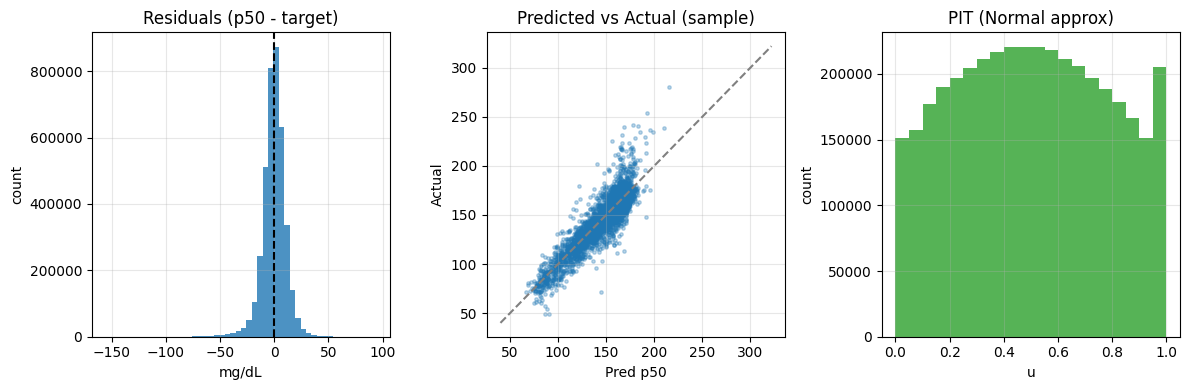

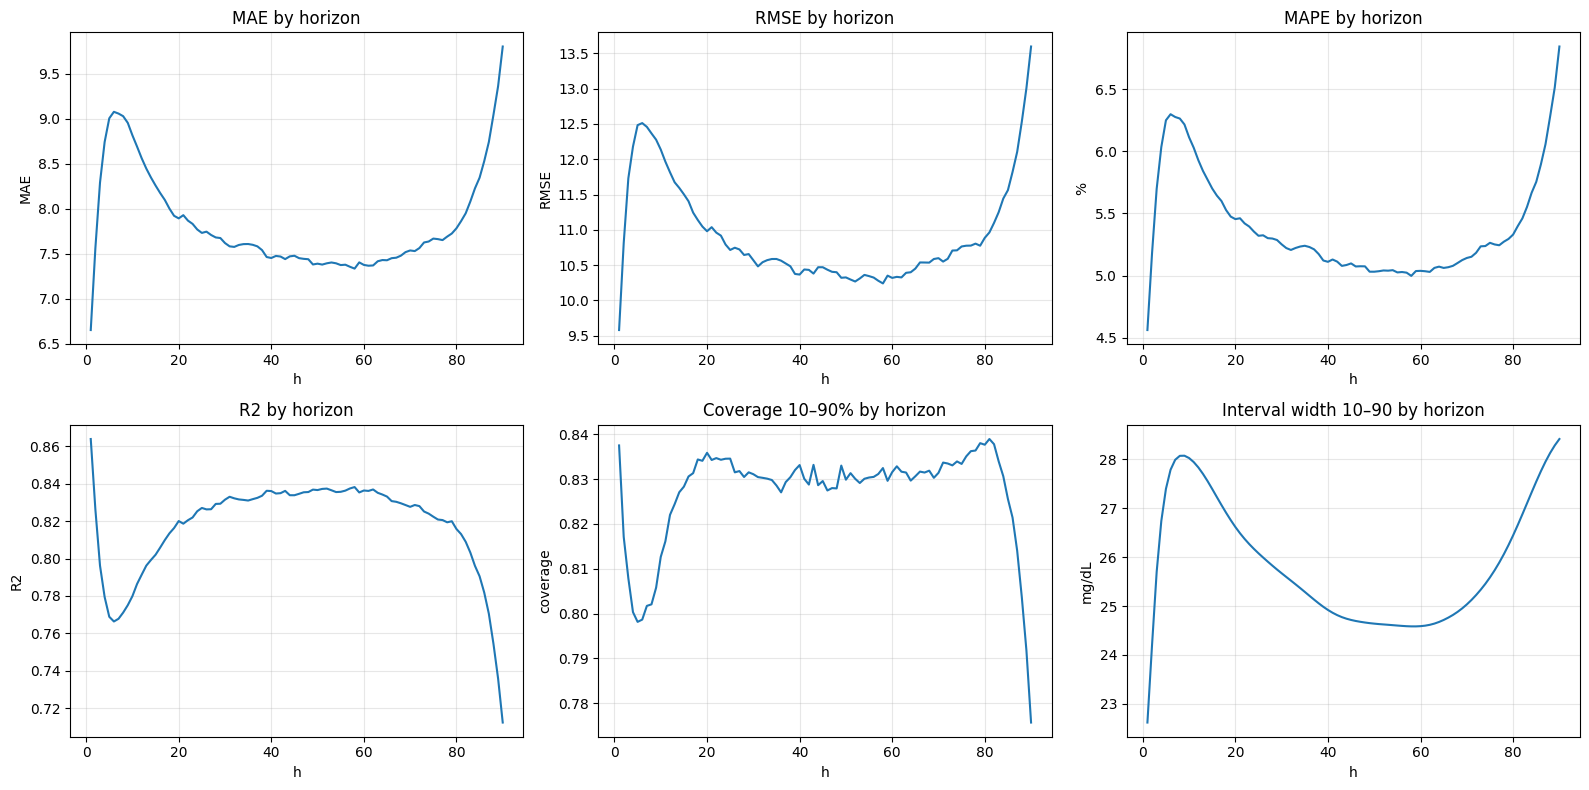

In [ ]:
# === TFT Regression Metrics: overall + per-horizon (no training) ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score
from scipy.stats import pearsonr, spearmanr, norm

# inputs: predictions (N,H,3), targets (N,H)
p10, p50, p90 = predictions[:,:,0], predictions[:,:,1], predictions[:,:,2]
tgt = targets

Z90 = 1.2815515655446004
sig = np.clip((p90 - p10) / (2 * Z90), 1e-6, 1e9)

# --- overall metrics ---
mae = mean_absolute_error(tgt.ravel(), p50.ravel())
rmse = np.sqrt(mean_squared_error(tgt.ravel(), p50.ravel()))
mape = np.mean(np.abs((p50.ravel() - tgt.ravel()) / np.clip(np.abs(tgt.ravel()), 1e-6, None))) * 100
medae = median_absolute_error(tgt.ravel(), p50.ravel())
r2 = r2_score(tgt.ravel(), p50.ravel())
pr, _ = pearsonr(p50.ravel(), tgt.ravel())
sr, _ = spearmanr(p50.ravel(), tgt.ravel())

# coverage + sharpness
cov_10_90 = np.mean((tgt >= p10) & (tgt <= p90))
iw_10_90 = np.mean(p90 - p10)

# quantile calibration (target ≤ qτ should be ≈ τ)
tau_list = [0.1, 0.5, 0.9]
qs = [p10, p50, p90]
qcal = {f"q{int(t*100)}": float(np.mean(tgt <= q)) for t, q in zip(tau_list, qs)}

# CRPS (normal approx)
def crps_norm(y, mu, sigma):
    z = (y - mu) / sigma
    pdf = norm.pdf(z)
    cdf = norm.cdf(z)
    return sigma * (z * (2*cdf - 1) + 2*pdf - 1/np.sqrt(np.pi))
crps = np.mean(crps_norm(tgt, p50, sig))

# --- per-horizon metrics ---
H = predictions.shape[1]
rows = []
for h in range(H):
    y = tgt[:, h]; yhat = p50[:, h]
    mae_h = mean_absolute_error(y, yhat)
    rmse_h = np.sqrt(mean_squared_error(y, yhat))
    mape_h = np.mean(np.abs((yhat - y) / np.clip(np.abs(y), 1e-6, None))) * 100
    r2_h = r2_score(y, yhat)
    cov_h = np.mean((tgt[:,h] >= p10[:,h]) & (tgt[:,h] <= p90[:,h]))
    iw_h = np.mean(p90[:,h] - p10[:,h])
    rows.append(dict(h=h+1, mae=mae_h, rmse=rmse_h, mape=mape_h, r2=r2_h, cov_10_90=cov_h, iw_10_90=iw_h))
df_h = pd.DataFrame(rows)

# --- print summary ---
print("=== TFT Regression (overall) ===")
print(f"MAE={mae:.2f} mg/dL | RMSE={rmse:.2f} | MAPE={mape:.2f}% | MedAE={medae:.2f} | R2={r2:.3f}")
print(f"Pearson r={pr:.3f} | Spearman ρ={sr:.3f}")
print(f"Coverage 10–90%={cov_10_90:.3f} | IntervalWidth 10–90={iw_10_90:.2f} mg/dL | CRPS≈{crps:.2f}")
print("Quantile calibration (empirical P[target ≤ qτ]):", qcal)

print("\n=== TFT Regression (per-horizon) head ===")
print(df_h.head(10).to_string(index=False))

# --- plots ---
# 1) Residuals
res = (p50 - tgt).ravel()
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.hist(res, bins=50, color='tab:blue', alpha=0.8)
plt.axvline(0, color='black', ls='--')
plt.title("Residuals (p50 - target)")
plt.xlabel("mg/dL"); plt.ylabel("count"); plt.grid(alpha=0.3)

# 2) Pred vs Actual (sample)
idx = np.random.choice(p50.size, size=min(5000, p50.size), replace=False)
plt.subplot(1,3,2)
plt.scatter(p50.ravel()[idx], tgt.ravel()[idx], s=6, alpha=0.3)
mn, mx = float(np.min(tgt)), float(np.max(tgt))
plt.plot([mn,mx],[mn,mx], '--', color='gray')
plt.title("Predicted vs Actual (sample)")
plt.xlabel("Pred p50"); plt.ylabel("Actual"); plt.grid(alpha=0.3)

# 3) PIT histogram (normal approx)
pit = norm.cdf((tgt - p50) / sig).ravel()
plt.subplot(1,3,3)
plt.hist(pit, bins=20, range=(0,1), color='tab:green', alpha=0.8)
plt.title("PIT (Normal approx)"); plt.xlabel("u"); plt.ylabel("count"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Horizon-wise curves
fig, axes = plt.subplots(2, 3, figsize=(16,8))
axes[0,0].plot(df_h['h'], df_h['mae']); axes[0,0].set_title("MAE by horizon"); axes[0,0].set_xlabel("h"); axes[0,0].set_ylabel("MAE"); axes[0,0].grid(alpha=0.3)
axes[0,1].plot(df_h['h'], df_h['rmse']); axes[0,1].set_title("RMSE by horizon"); axes[0,1].set_xlabel("h"); axes[0,1].set_ylabel("RMSE"); axes[0,1].grid(alpha=0.3)
axes[0,2].plot(df_h['h'], df_h['mape']); axes[0,2].set_title("MAPE by horizon"); axes[0,2].set_xlabel("h"); axes[0,2].set_ylabel("%"); axes[0,2].grid(alpha=0.3)
axes[1,0].plot(df_h['h'], df_h['r2']); axes[1,0].set_title("R2 by horizon"); axes[1,0].set_xlabel("h"); axes[1,0].set_ylabel("R2"); axes[1,0].grid(alpha=0.3)
axes[1,1].plot(df_h['h'], df_h['cov_10_90']); axes[1,1].set_title("Coverage 10–90% by horizon"); axes[1,1].set_xlabel("h"); axes[1,1].set_ylabel("coverage"); axes[1,1].grid(alpha=0.3)
axes[1,2].plot(df_h['h'], df_h['iw_10_90']); axes[1,2].set_title("Interval width 10–90 båçy horizon"); axes[1,2].set_xlabel("h"); axes[1,2].set_ylabel("mg/dL"); axes[1,2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

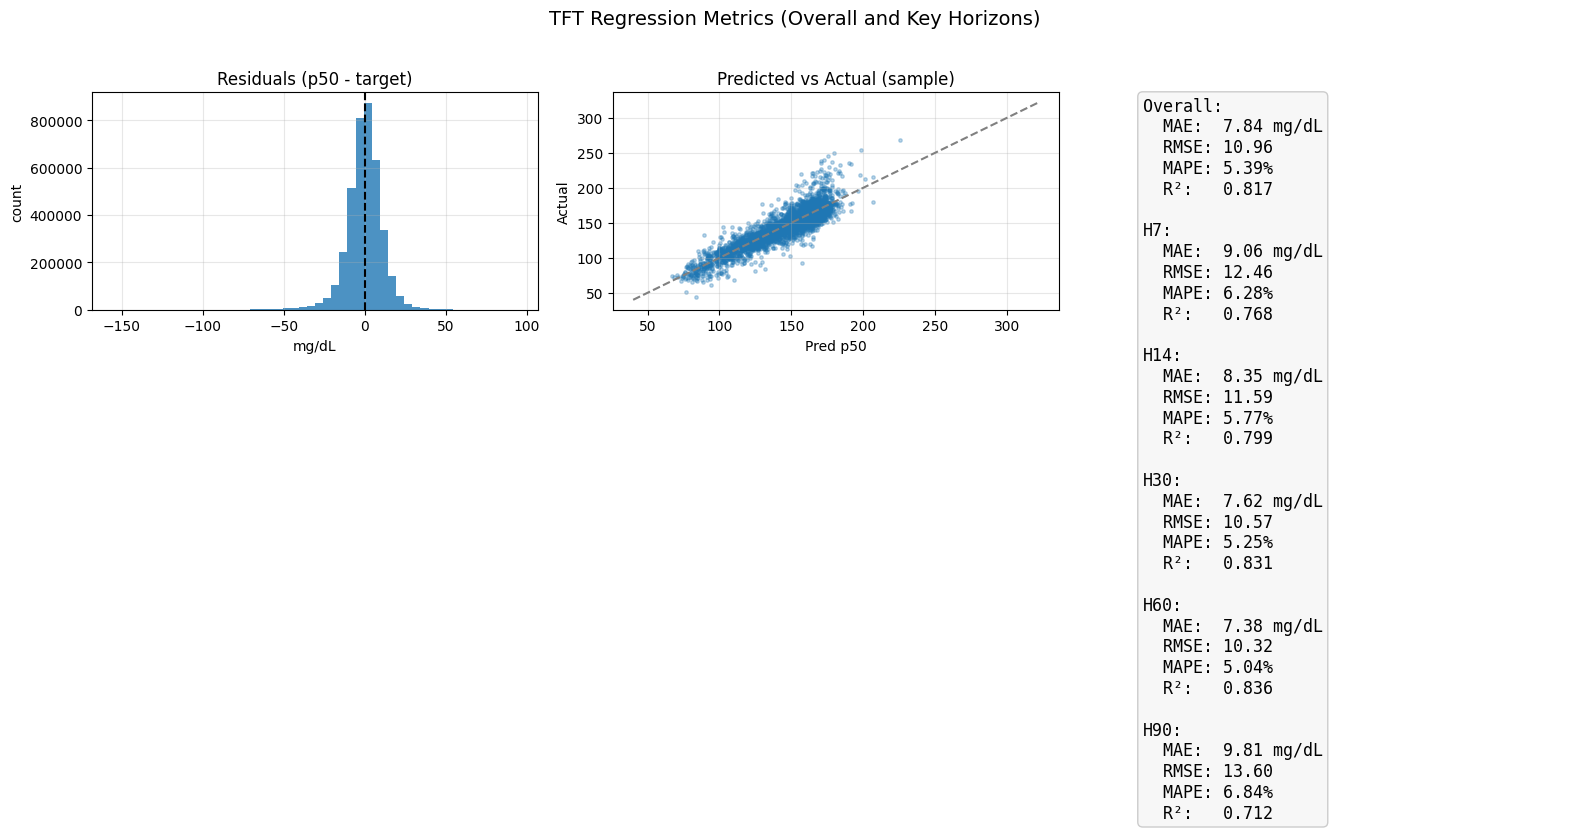

In [29]:
# === TFT Regression Metrics Figure (Overall + H=7/14/30/60/90 on image) ===
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Assumes: predictions (N,H,3), targets (N,H) already defined
p10, p50, p90 = predictions[:,:,0], predictions[:,:,1], predictions[:,:,2]
tgt = targets

def reg_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = float(np.mean(np.abs((y_pred - y_true) / np.clip(np.abs(y_true), 1e-6, None))) * 100)
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, mape, r2

# Overall
mae_o, rmse_o, mape_o, r2_o = reg_metrics(tgt.ravel(), p50.ravel())

# Horizons of interest (clip to available)
H = p50.shape[1]
horizons = [h for h in [7, 14, 30, 60, 90] if h <= H]

per_h = {}
for h in horizons:
    y = tgt[:, h-1]
    yhat = p50[:, h-1]
    per_h[h] = reg_metrics(y, yhat)

# Build multi-panel figure (left: residuals hist; middle: scatter; right: metrics board)
fig = plt.figure(figsize=(16, 6))

# Residuals histogram
ax1 = fig.add_subplot(1, 3, 1)
res = (p50 - tgt).ravel()
ax1.hist(res, bins=50, color='tab:blue', alpha=0.8)
ax1.axvline(0, color='black', ls='--')
ax1.set_title("Residuals (p50 - target)")
ax1.set_xlabel("mg/dL")
ax1.set_ylabel("count")
ax1.grid(alpha=0.3)

# Pred vs actual (sample)
ax2 = fig.add_subplot(1, 3, 2)
idx = np.random.choice(p50.size, size=min(5000, p50.size), replace=False)
ax2.scatter(p50.ravel()[idx], tgt.ravel()[idx], s=6, alpha=0.3)
mn, mx = float(np.min(tgt)), float(np.max(tgt))
ax2.plot([mn, mx], [mn, mx], '--', color='gray')
ax2.set_title("Predicted vs Actual (sample)")
ax2.set_xlabel("Pred p50")
ax2.set_ylabel("Actual")
ax2.grid(alpha=0.3)

# Metrics board (text rendered inside the image)
ax3 = fig.add_subplot(1, 3, 3)
ax3.axis('off')

lines = []
lines.append("Overall:")
lines.append(f"  MAE:  {mae_o:.2f} mg/dL")
lines.append(f"  RMSE: {rmse_o:.2f}")
lines.append(f"  MAPE: {mape_o:.2f}%")
lines.append(f"  R²:   {r2_o:.3f}")
lines.append("")

for h in horizons:
    mae_h, rmse_h, mape_h, r2_h = per_h[h]
    lines.append(f"H{h}:")
    lines.append(f"  MAE:  {mae_h:.2f} mg/dL")
    lines.append(f"  RMSE: {rmse_h:.2f}")
    lines.append(f"  MAPE: {mape_h:.2f}%")
    lines.append(f"  R²:   {r2_h:.3f}")
    lines.append("")

# Render the text nicely within the axes
txt = "\n".join(lines).rstrip()
ax3.text(0.02, 0.98, txt, va='top', ha='left', fontsize=12, family='monospace',
         bbox=dict(boxstyle='round', facecolor='#f7f7f7', edgecolor='#cccccc'))

fig.suptitle("TFT Regression Metrics (Overall and Key Horizons)", fontsize=14, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()